# 05. AI-based Learning Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Build and evaluate common AI/ML models
- Compare model families and deployment considerations

## 🔗 Where this fits

**Builds on:** Course 02 — Units 1-4 (search, knowledge, uncertainty, optimization) and Course 01 (AIAT 111) — Unit 2, lesson 06, where these model families were first trained: training a model is optimization over a representation.

**Used later in:** Course 04 (AIAT 114) — the whole course, which turns this survey into a full algorithms curriculum.

---


# 05. AI-based Learning Models

---

## The Story: Teaching Machines to Learn

**THE PROBLEM**: We want machines to make predictions or decisions, but we can't program every rule manually!

**BEFORE**: We manually write rules for everything - "if height > 180cm then tall" - but this doesn't work for complex patterns.
**AFTER**: We use machine learning - show examples to the machine and let it learn patterns automatically!

---

## ❌ THE PROBLEM: Why Machine Learning Matters

**Problem 1**: We need machines to recognize patterns or make predictions
- Spam detection: Can't write rules for all spam patterns
- Image recognition: Can't describe what a cat looks like in code
- Price prediction: Too many factors to code manually

**Problem 2**: Without machine learning, we:
- Write manual rules (doesn't work for complex patterns)
- Can't adapt to new data (rules become outdated)
- Can't handle high-dimensional data (too many features)

**WHY IT MATTERS**: Manual rules don't work for complex real-world problems - we need machines that learn!

---

## ✅ THE SOLUTION: Machine Learning Models

**Solution**: Use machine learning algorithms that:
1. **Learn from data**: See examples and find patterns
2. **Generalize**: Make predictions on new, unseen data
3. **Adapt**: Improve with more data

**HOW IT SOLVES IT**:
- ✅ Instead of manual rules → Learned patterns from data
- ✅ Instead of rigid code → Flexible models that adapt
- ✅ Instead of guessing relationships → Models discover patterns from examples

## Learning Objectives
1. Understand the PROBLEM of pattern recognition
2. Learn the SOLUTION: Machine learning models
3. See HOW they solve real-world problems
4. Compare BEFORE (manual rules) vs AFTER (learned models)


## 🌍 The case: the week hand-written rules lost the spam war

**August 2002.** Spam filtering was a rules arms race: engineers wrote patterns for "V1AGRA" and "FREE!!!", spammers changed the spelling, engineers wrote more patterns. Paul Graham's essay *A Plan for Spam* proposed throwing the rules away and training a naive-Bayesian filter on examples instead — corpora of roughly **4,000 spam and 4,000 legitimate messages** from his own mail. His reported result: *"we now miss less than 5 per 1000 spams, with 0 false positives."*

Nobody had written a rule for any particular word. The filter *counted*, in real mail, which words appeared in which kind of message. Within a couple of years every major mail provider had moved to statistical filtering, and the pattern lists were gone.

**And the data on this page is equally real, with equally specific provenance.** That matters, because a model is a claim about the population it learned from:

- **California housing** — 20,640 block groups from the **1990 US census** (Pace & Barry, 1997). The relationship between income and house value is not generated by any formula; it has to be measured.
- **Breast tumour biopsies** — the **Wisconsin Diagnostic Breast Cancer** set: 569 cases whose 30 features were computed from digitised images of fine-needle aspirates by Street, Wolberg & Mangasarian at the University of Wisconsin (1993). The label is an actual pathology result on an actual patient.
- **Irises** — Edgar Anderson's **1935** field measurements of 150 flowers, made famous by Fisher in 1936.

### What goes wrong without this

Run the "❌ BEFORE" cell below and watch the failure directly: hand-written price rules — *if income < \$20,000 then value = \$100,000* — drawn over the real census data as a staircase that steps straight past the points.

Two things break, and the second is the expensive one:

1. **Nobody can write enough rules.** Two variables are manageable. The tumour dataset has thirty measurements per biopsy; the interactions between them are not something a human writes down.
2. **Rules go stale silently.** New spam wording, a new neighbourhood, a new scanner in the pathology lab — the rules keep firing, keep returning confident answers, and nothing in the system tells you they stopped matching the world. A learned model has the same problem, but at least it comes with a measured error you can re-measure.

---


## Part 1: ❌ BEFORE - Manual Rules (The Problem)

**THE PROBLEM**: Trying to solve problems with manual rules.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# ❌ THE PROBLEM: Using manual rules
# Example: Predicting house prices

print("=" * 70)
print("❌ BEFORE: The Problem - Manual Rules")
print("=" * 70)
print()
print("Problem: Predict the median house value of a US neighbourhood")
print("         from the median income of the people who live in it")
print("         (real data: 1990 US census, California)")
print()
print("❌ APPROACH: Write manual rules")
print("   if median income < $20,000: value = $100,000")
print("   elif median income < $40,000: value = $200,000")
print("   elif median income < $60,000: value = $300,000")
print("   else: value = $500,000")
print()
print("❌ PROBLEMS:")
print("   1. Rules are arbitrary (why 100k? why 200k?)")
print("   2. Doesn't account for location, age, condition...")
print("   3. Can't adapt to market changes")
print("   4. Doesn't learn from real data")
print()
print("🤔 WHY THIS IS A PROBLEM:")
print("   • Real-world problems are complex (many factors)")
print("   • Patterns change over time")
print("   • Can't write rules for everything")
print()
print("💡 THE SOLUTION: Use machine learning - let the model learn from data!")

❌ BEFORE: The Problem - Manual Rules

Problem: Predict the median house value of a US neighbourhood
         from the median income of the people who live in it
         (real data: 1990 US census, California)

❌ APPROACH: Write manual rules
   if median income < $20,000: value = $100,000
   elif median income < $40,000: value = $200,000
   elif median income < $60,000: value = $300,000
   else: value = $500,000

❌ PROBLEMS:
   1. Rules are arbitrary (why 100k? why 200k?)
   2. Doesn't account for location, age, condition...
   3. Can't adapt to market changes
   4. Doesn't learn from real data

🤔 WHY THIS IS A PROBLEM:
   • Real-world problems are complex (many factors)
   • Patterns change over time
   • Can't write rules for everything

💡 THE SOLUTION: Use machine learning - let the model learn from data!


## Part 2: ✅ AFTER - Machine Learning (The Solution)

**THE SOLUTION**: Use machine learning to learn patterns from data!

In [2]:
# ✅ THE SOLUTION: Machine Learning
# Show the model examples, let it learn the pattern!

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("✅ AFTER: The Solution - Machine Learning")
print("=" * 70)
print()

# REAL DATA: the California Housing dataset — 20,640 census block groups from the
# 1990 US census, each with a median household income and a median house value.
# Nobody chose these numbers; they are what the census recorded.
print("   ⏰ WHEN to use: Always start from real data — real relationships are what you must learn to model")
print("   💡 WHY use: On real data the model CANNOT fit perfectly, and that gap is the lesson")

california = fetch_california_housing()
housing = pd.DataFrame(california.data, columns=california.feature_names)
housing["MedHouseVal"] = california.target

# Classroom-size the data honestly: a 400-block-group random sample, random_state=42.
housing = housing.sample(n=400, random_state=42).reset_index(drop=True)

X = housing[["MedInc"]].to_numpy()          # median household income, in tens of thousands of $
y = housing["MedHouseVal"].to_numpy()       # median house value, in hundreds of thousands of $

print("📊 Step 1: Show REAL examples to the model (training data)")
print(f"   • {len(X)} real census block groups, sampled from {california.data.shape[0]:,} (random_state=42)")
print(f"   • Feature: median household income  (${X.min() * 10_000:,.0f} to ${X.max() * 10_000:,.0f})")
print(f"   • Target:  median house value       (${y.min() * 100_000:,.0f} to ${y.max() * 100_000:,.0f})")
print(f"   • Nobody told the model the relationship — it must find it in the data")
print()

# Split data: some for training (learning), some for testing (evaluating)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Split data: 80% for training (model learns from this), 20% for testing (model evaluated on this - unseen data!)

print("📊 Step 2: Train the model (let it learn from examples)")
print("   ⏰ WHEN to use: AFTER splitting data - train model on training set")
print("   💡 WHY use: This is where model LEARNS - finds the relationship between size and price!")

model = LinearRegression()  # Create learning model: Initialize empty linear regression model (no parameters needed - learns everything from data!)
model.fit(X_train, y_train)  # Train it: Show training examples to model, let it learn the pattern (this is where learning happens - model adjusts its weights!)

print(f"   ✅ Model learned: value = {model.coef_[0]:.4f} × income + {model.intercept_:.4f}")  # Show learned relationship: the slope and intercept fitted from real data
print(f"   Reading it in dollars: every extra $10,000 of median income goes with about "
      f"${model.coef_[0] * 100_000:,.0f} more house value")  # Translate the slope into units a person can check
print(f"   ⚠️  There is no 'true' equation to compare against here — real house prices are")
print(f"      not generated by a formula. All we can do is measure how well the line fits.")
print()

# Test on new data (data it hasn't seen before)
print("   ⏰ WHEN to use: AFTER training - predict on new, unseen test data")
print("   💡 WHY use: Test if model generalizes - can it predict on data it hasn't seen? (prevents overfitting!)")

y_pred = model.predict(X_test)  # Make predictions: Use trained model to predict prices for test houses (model has never seen these before!)
accuracy = r2_score(y_test, y_pred)  # How well it predicts: Calculate R² score - measures how well predictions match actual values (1.0 = perfect, <1 = some error)

print("📊 Step 3: Test the model on new data")
print(f"   ✅ R² Score: {accuracy:.4f} (1.0 = perfect, closer to 1 is better)")  # Show accuracy: how much of the real variation the line explains
print(f"   ✅ Typical error: ${np.sqrt(((y_test - y_pred) ** 2).mean()) * 100_000:,.0f}")  # RMSE converted to dollars so the error is meaningful
print(f"   ✅ The model found a real pattern — but far from all of it.")  # Honest framing of a mid-range R²
print(f"      Income is only one of many things that set a house price: location,")
print(f"      house age, number of rooms and the ocean view are all missing here.")
print()

print("🔗 HOW THIS SOLVES THE PROBLEM:")
print("   ❌ BEFORE: Manual rules → Arbitrary, doesn't learn from data")
print("   ✅ AFTER: Machine learning → Learns from examples, finds real pattern!")
print("   • Instead of guessing rules → Learns from data")
print("   • Instead of rigid → Adapts to real patterns")
print("   • Instead of arbitrary → Based on actual relationships!")

✅ AFTER: The Solution - Machine Learning

   ⏰ WHEN to use: Always start from real data — real relationships are what you must learn to model
   💡 WHY use: On real data the model CANNOT fit perfectly, and that gap is the lesson
📊 Step 1: Show REAL examples to the model (training data)
   • 400 real census block groups, sampled from 20,640 (random_state=42)
   • Feature: median household income  ($8,527 to $150,001)
   • Target:  median house value       ($45,800 to $500,001)
   • Nobody told the model the relationship — it must find it in the data

📊 Step 2: Train the model (let it learn from examples)
   ⏰ WHEN to use: AFTER splitting data - train model on training set
   💡 WHY use: This is where model LEARNS - finds the relationship between size and price!
   ✅ Model learned: value = 0.3696 × income + 0.6253
   Reading it in dollars: every extra $10,000 of median income goes with about $36,961 more house value
   ⚠️  There is no 'true' equation to compare against here — real house pr

/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_63404/2464093278.py:35: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_63404/2464093278.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


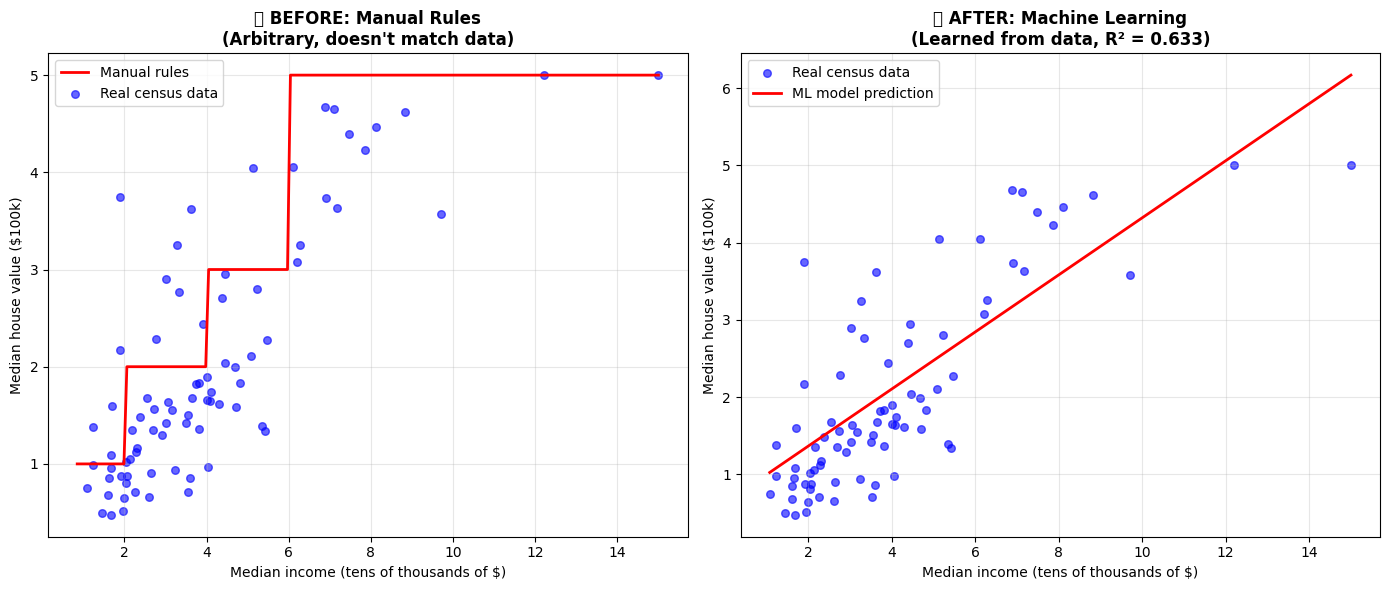

📊 BEFORE vs AFTER Comparison (measured on the same real test set):
   BEFORE: hand-written rules  → R² = 0.384
   AFTER:  learned linear model → R² = 0.633

   Notice the flat line at the top-right of the real scatter: the census capped
   recorded house values at $500,001, so hundreds of real block groups sit exactly
   on that ceiling. No model can predict past a cap in the measurement itself —
   a quirk that only real data can teach you to look for.


In [3]:
# Put the two approaches side by side on the SAME test data: hand-written price rules vs the learned model.
# Why: seeing the staircase of manual rules miss the data makes the case for learning from examples.
import numpy as np
# Visualize: BEFORE vs AFTER comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# BEFORE: Manual rules (arbitrary), drawn over the SAME real data
income_grid = np.linspace(X.min(), X.max(), 200)
manual_value = np.where(income_grid < 2, 1.0,
                 np.where(income_grid < 4, 2.0,
                   np.where(income_grid < 6, 3.0, 5.0)))
ax1.plot(income_grid, manual_value, 'r-', linewidth=2, label='Manual rules')
ax1.scatter(X_test, y_test, alpha=0.6, color='blue', s=30, label='Real census data')
ax1.set_xlabel('Median income (tens of thousands of $)')
ax1.set_ylabel('Median house value ($100k)')
ax1.set_title('❌ BEFORE: Manual Rules\n(Arbitrary, doesn\'t match data)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AFTER: Machine learning (learned from data)
# Sort data for smooth line plot
sort_idx = np.argsort(X_test.flatten())
X_test_sorted = X_test[sort_idx]
y_pred_sorted = y_pred[sort_idx]
y_test_sorted = y_test[sort_idx]

ax2.scatter(X_test, y_test, alpha=0.6, color='blue', s=30, label='Real census data')
ax2.plot(X_test_sorted, y_pred_sorted, 'r-', linewidth=2, label='ML model prediction')
ax2.set_xlabel('Median income (tens of thousands of $)')
ax2.set_ylabel('Median house value ($100k)')
ax2.set_title(f'✅ AFTER: Machine Learning\n(Learned from data, R² = {accuracy:.3f})', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Score the manual rules on exactly the same test set, so the comparison is a measurement.
manual_pred = np.where(X_test.ravel() < 2, 1.0,
                np.where(X_test.ravel() < 4, 2.0,
                  np.where(X_test.ravel() < 6, 3.0, 5.0)))
manual_r2 = 1 - ((y_test - manual_pred) ** 2).sum() / ((y_test - y_test.mean()) ** 2).sum()

print("📊 BEFORE vs AFTER Comparison (measured on the same real test set):")
print(f"   BEFORE: hand-written rules  → R² = {manual_r2:.3f}")
print(f"   AFTER:  learned linear model → R² = {accuracy:.3f}")
print()
print("   Notice the flat line at the top-right of the real scatter: the census capped")
print("   recorded house values at $500,001, so hundreds of real block groups sit exactly")
print("   on that ceiling. No model can predict past a cap in the measurement itself —")
print("   a quirk that only real data can teach you to look for.")

**📊 Read the figure — both panels show the *same* real California block groups.**

*Left, the hand-written rule:* the red staircase jumps at incomes of 2, 4 and 6 (that is $20k, $40k, $60k) and then flat-lines. Nobody derived those thresholds from anything — a person guessed them. Look at how the blue dots behave around it: below an income of 4 the staircase sits *above* most of the cloud, and past an income of 6 it sits *below* neighbourhoods worth far less than the step it assigned them. The rule is not slightly wrong; it is wrong in a different direction in each band.

*Right, the fitted line:* the same kind of red line, but its slope and intercept were computed from the training rows instead of guessed. It now runs through the middle of the cloud and follows its upward tilt. The R² in the title is the fraction of the real variation it accounts for — and the scatter still spread around the line is everything that median income alone cannot tell you about a neighbourhood. Neither panel is a "perfect" model; the difference on show is *guessed* versus *fitted*.

## Part 3: K-Nearest Neighbors (KNN)

**The Story**: Some problems don't have clear patterns - but similar things are usually close together!

**BEFORE**: We try to find a mathematical formula, but the pattern is too complex or non-linear.
**AFTER**: KNN uses a simple idea - "similar things are close" - to make predictions without complex formulas!

We test that idea on **real measurements**: Edgar Anderson's 1935 iris survey, using the two
species that genuinely overlap (*versicolor* and *virginica*). If "similar things are close"
is true, a flower's nearest neighbours should mostly share its species — and where the two
species really do overlap, KNN will get some wrong. Both halves of that sentence matter.

✅ AFTER: K-Nearest Neighbors (KNN) on real flower measurements

📊 Training data (real flowers):
   • 45 versicolor (class 0)
   • 46 virginica (class 1)
   Features: [petal length (cm), petal width (cm)]
   • 9 further real flowers held back to test on

✅ Created KNN classifier (k=3)
  ✅ Stored 91 training examples
📊 Predictions on real held-out flowers:
   Flower 1: petal 4.5 x 1.5 cm → predicted Versicolor  (actually Versicolor) ✅
   Flower 2: petal 5.0 x 1.9 cm → predicted Virginica   (actually Virginica) ✅
   Flower 3: petal 5.1 x 1.9 cm → predicted Virginica   (actually Virginica) ✅
   Flower 4: petal 4.0 x 1.2 cm → predicted Versicolor  (actually Versicolor) ✅
   Flower 5: petal 5.0 x 1.5 cm → predicted Versicolor  (actually Virginica) ❌
   Flower 6: petal 4.9 x 1.8 cm → predicted Virginica   (actually Virginica) ✅
   Flower 7: petal 3.6 x 1.3 cm → predicted Versicolor  (actually Versicolor) ✅
   Flower 8: petal 3.3 x 1.0 cm → predicted Versicolor  (actually Versicolor) ✅
   Flow

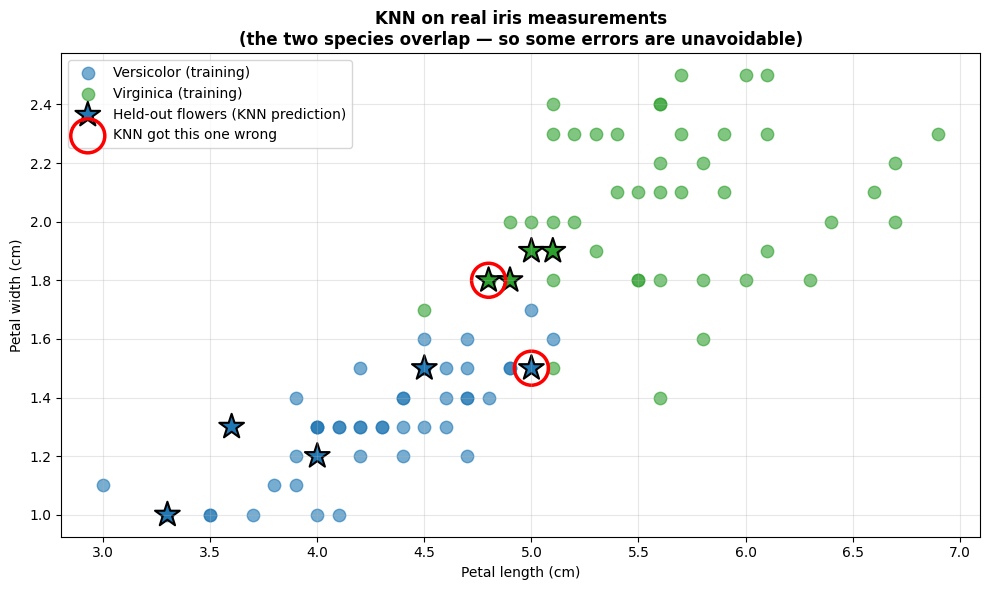

In [4]:
# K-Nearest Neighbors (KNN) Algorithm
# BEFORE: Complex patterns are hard to model with formulas
# AFTER: KNN uses simple idea - "similar things are close" - to predict!

import numpy as np
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

class KNN:
    """
    K-Nearest Neighbors: Simple but powerful classification algorithm.
    
    THE PROBLEM: Complex patterns can't be captured by simple formulas.
    THE SOLUTION: Use the simple idea - "similar things are close together"!
    
    How it works:
    1. Store all training examples
    2. For new example, find K nearest neighbors
    3. Predict based on majority class of neighbors
    """
    def __init__(self, k=3):
        """
        Initialize KNN classifier.
        
        Parameters:
        - k: Number of neighbors to consider (usually odd: 3, 5, 7)
        """
        self.k = k
        self.X_train = None  # Training features
        self.y_train = None  # Training labels
        print(f"✅ Created KNN classifier (k={k})")
    
    def fit(self, X, y):
        """
        Train the model (just store the data - KNN is "lazy" learning!).
        
        Unlike other algorithms, KNN doesn't "learn" a formula.
        It just remembers all examples - that's why it's called "lazy"!
        """
        self.X_train = np.array(X)  # Store training features
        self.y_train = np.array(y)  # Store training labels
        print(f"  ✅ Stored {len(X)} training examples")
    
    def predict(self, X):
        """
        Predict class for new examples.
        
        THE SOLUTION:
        1. For each new example, find K nearest neighbors
        2. Look at their classes
        3. Predict the majority class
        """
        X = np.array(X)  # Convert to numpy array
        predictions = []  # Store predictions
        
        for x in X:
            # Calculate distances to all training examples
            # Distance = how "far" is this example from each training example?
            distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            
            # Find K nearest neighbors (smallest distances)
            k_indices = np.argsort(distances)[:self.k]  # Indices of K nearest
            k_nearest_labels = self.y_train[k_indices]  # Classes of K nearest
            
            # Predict majority class (most common class among neighbors)
            majority_class = Counter(k_nearest_labels).most_common(1)[0][0]
            predictions.append(majority_class)
        
        return np.array(predictions)

# Example: classifying REAL iris flowers by petal measurements
print("=" * 70)
print("✅ AFTER: K-Nearest Neighbors (KNN) on real flower measurements")
print("=" * 70)
print()

# REAL DATA: 150 iris flowers measured with a ruler by Edgar Anderson (1935).
# We keep the two species that genuinely overlap — separating setosa would be trivial
# and would teach us nothing about where KNN struggles.
iris = load_iris()
mask = iris.target > 0                       # 1 = versicolor, 2 = virginica
X = iris.data[mask][:, 2:4]                  # petal length, petal width (cm)
y = (iris.target[mask] == 2).astype(int)     # 0 = versicolor, 1 = virginica
species_names = ["Versicolor", "Virginica"]

# Hold out real flowers as the test set — never invented points.
X, X_new, y, y_new = train_test_split(X, y, test_size=9, random_state=42, stratify=y)

print("📊 Training data (real flowers):")
print(f"   • {int((y == 0).sum())} versicolor (class 0)")
print(f"   • {int((y == 1).sum())} virginica (class 1)")
print("   Features: [petal length (cm), petal width (cm)]")
print(f"   • {len(X_new)} further real flowers held back to test on")
print()

# Train KNN
knn = KNN(k=3)
knn.fit(X, y)

# Test on the held-out REAL flowers
test_points = X_new
predictions = knn.predict(test_points)

print("📊 Predictions on real held-out flowers:")
for i, (point, pred, truth) in enumerate(zip(test_points, predictions, y_new)):
    mark = "✅" if pred == truth else "❌"
    print(f"   Flower {i+1}: petal {point[0]:.1f} x {point[1]:.1f} cm → "
          f"predicted {species_names[pred]:<11} (actually {species_names[truth]}) {mark}")

n_correct = int((predictions == y_new).sum())
print()
print(f"   Correct: {n_correct} of {len(y_new)} ({n_correct / len(y_new):.0%})")

print("\n🔗 HOW THIS SOLVES THE PROBLEM:")
print("   ❌ BEFORE: Need complex formula for pattern")
print("   ✅ AFTER: KNN uses simple idea - 'similar things are close'!")
print("   • No formula needed - just find nearest neighbors")
print("   • Works for complex, non-linear patterns")
print("   • Simple but powerful!")
print()
print("   ⚠️  On real data the two species overlap where their petals are similar sizes.")
print("      Any mistake above sits in that overlap — it is nature being ambiguous,")
print("      not the algorithm being broken.")

# Visualize the real measurements and the held-out flowers KNN had to label
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='tab:blue', label='Versicolor (training)', s=80, alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='tab:green', label='Virginica (training)', s=80, alpha=0.6)
plt.scatter(test_points[:, 0], test_points[:, 1],
            c=['tab:blue' if p == 0 else 'tab:green' for p in predictions],
            marker='*', s=350, label='Held-out flowers (KNN prediction)',
            edgecolors='black', linewidths=1.5)
wrong = predictions != y_new
if wrong.any():
    plt.scatter(test_points[wrong, 0], test_points[wrong, 1], facecolors='none',
                edgecolors='red', s=600, linewidths=2.5, label='KNN got this one wrong')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('KNN on real iris measurements\n(the two species overlap — so some errors are unavoidable)',
          fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**📊 Read the figure.** Blue dots are versicolor, green dots are virginica — 91 real flowers from Anderson's 1935 measurements. The nine stars are the held-out flowers, each coloured by *what KNN predicted*, and the two red rings mark the two it got wrong.

Notice **where** the rings are. Both sit at a petal length of roughly 4.8–5.0 cm and a width of 1.5–1.8 cm — the band in the middle of the plot where blue and green dots are interleaved. Every star out in the clean blue territory at the lower left was labelled correctly. The mistakes are not scattered at random across the plot: they are precisely where the two species genuinely overlap in these two measurements. 7 correct out of 9 is close to the ceiling this pair of features allows, not evidence that the algorithm is broken.

---

**Note**: KNN is a "lazy" learning algorithm - it doesn't build a model during training, it just stores the data. When making predictions, it finds the nearest neighbors. This makes it simple but can be slow for large datasets!


## Part 4: Logistic Regression

### 📚 Prerequisites (What You Need First)
- ✅ **Linear Regression** (from Part 2) - Understanding regression models
- ✅ **Probability** (from Notebook 3) - Understanding probabilities (0 to 1)
- ✅ **Classification concepts** - Understanding class labels (0/1, Yes/No)

### 🔗 Relationship: What This Builds On
This comes **AFTER** Linear Regression - it's for classification problems!
- Builds on: Linear Regression (similar structure, different output)
- Alternative to: KNN, Decision Trees (different classification approach)
- Best for: Binary classification (two classes)

### 📖 The Story
Linear Regression predicts continuous values (like a house value), but what if we want to
predict categories (like "malignant" or "benign")?

We use **real diagnostic data**: 569 breast-tumour biopsies from the Wisconsin Diagnostic
study, where the label is an actual pathology result. Here a probability is not a nicety —
a doctor needs to know whether the model is 51% sure or 99% sure.

**Before Logistic Regression**: We can't use linear regression for classification - it outputs continuous values.
**After Logistic Regression**: We use logistic function to output probabilities (0 to 1), perfect for classification!

---

### ⏰ WHEN to use Logistic Regression:
- Binary classification (2 classes: Yes/No, Spam/Ham, 0/1)
- Need probability estimates (not just class labels)
- Linearly separable data (decision boundary is a line)
- Interpretable model (understand feature importance)

### 💡 WHY use Logistic Regression:
- Outputs probabilities (0 to 1) - know confidence in predictions
- Interpretable - coefficients show feature importance
- Fast training and prediction
- Good baseline for classification problems
- Foundation for neural networks!

✅ AFTER: Logistic Regression (Binary Classification)

📊 THE PROBLEM:
   • Linear Regression predicts continuous values (price, temperature)
   • But we need to predict CATEGORIES (malignant/benign, pass/fail)
   • Categories are discrete (0 or 1), not continuous!

✅ THE SOLUTION: Logistic Regression
   • Uses 'logistic function' (S-shaped curve) to output probabilities
   • Probability between 0 and 1 (perfect for classification!)
   • Probability > 0.5 → Class 1, Probability < 0.5 → Class 0

📊 Example: Real Tumour Diagnosis (Wisconsin Diagnostic Breast Cancer)
   Features: [mean radius of cell nuclei, mean texture]
   Label: 0 = Benign, 1 = Malignant

   Training data: 569 real biopsies
   • 357 Benign (class 0)
   • 212 Malignant (class 1)
   Real class balance: 37.3% malignant — not the tidy 50/50 of a made-up example
   Features: [mean radius (µm-scale), mean texture]

📊 Step 1: Train Logistic Regression Model
   ⏰ WHEN to use: AFTER splitting data - train on training set
   💡 WHY 

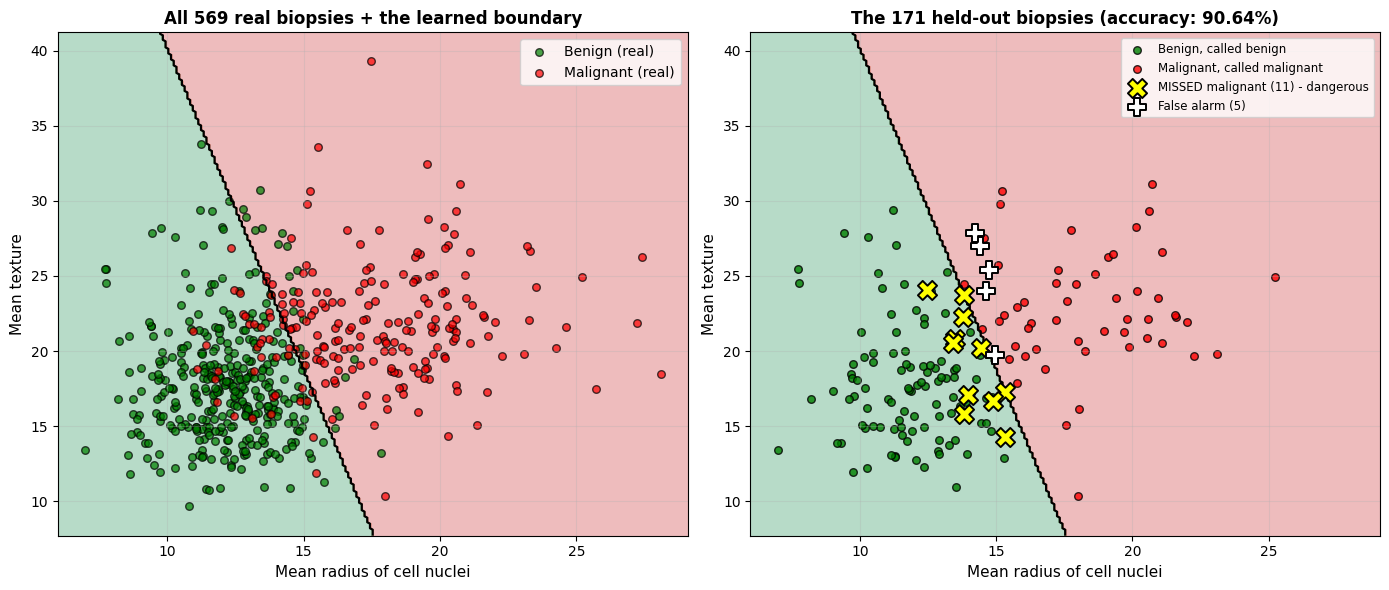

📊 Visualization Explanation:
   • Green region = Predicted 'Benign'
   • Red region = Predicted 'Malignant'
   • Black line   = Where probability = 0.5 (the decision threshold)
   • Yellow X     = a malignant tumour the model called benign (the dangerous miss)
   • White +      = a benign tumour the model called malignant (a false alarm)
   • Model learned to separate the two real diagnoses — imperfectly, because
     real benign and malignant tumours overlap in size and texture.

   Confusion matrix on the real test biopsies:
      Benign correctly called benign      : 103
      Benign wrongly called malignant     : 5  (false alarm)
      Malignant MISSED (called benign)    : 11  ← the dangerous error
      Malignant correctly called malignant: 52
   Recall on malignant tumours: 82.5%
   Accuracy alone would have hidden those missed cases.

🔗 HOW THIS SOLVES THE PROBLEM:
   ❌ BEFORE: Can't use Linear Regression for classification (wrong output type)
   ✅ AFTER: Logistic Regression out

In [5]:
# Logistic Regression: Binary Classification with Probabilities
# ⏰ WHEN to use: Binary classification (2 classes) - need probability estimates!
# 💡 WHY use: Outputs probabilities (0-1) - know confidence, interpretable coefficients!

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("✅ AFTER: Logistic Regression (Binary Classification)")
print("=" * 70)
print()

# THE PROBLEM: Binary Classification
print("📊 THE PROBLEM:")
print("   • Linear Regression predicts continuous values (price, temperature)")
print("   • But we need to predict CATEGORIES (malignant/benign, pass/fail)")
print("   • Categories are discrete (0 or 1), not continuous!")
print()
print("✅ THE SOLUTION: Logistic Regression")
print("   • Uses 'logistic function' (S-shaped curve) to output probabilities")
print("   • Probability between 0 and 1 (perfect for classification!)")
print("   • Probability > 0.5 → Class 1, Probability < 0.5 → Class 0")
print()

# REAL DATA: Wisconsin Diagnostic Breast Cancer — 569 biopsies, measurements taken
# from digitised images of cell nuclei, labelled by the pathology result.
# Label: 1 = Malignant, 0 = Benign  (we flip sklearn's coding so 1 = the thing we hunt for)
print("📊 Example: Real Tumour Diagnosis (Wisconsin Diagnostic Breast Cancer)")
print("   Features: [mean radius of cell nuclei, mean texture]")
print("   Label: 0 = Benign, 1 = Malignant")
print()

cancer = load_breast_cancer()
# Two of the 30 real features, chosen so the decision boundary can be drawn in 2D.
X = cancer.data[:, [0, 1]]                      # mean radius, mean texture
y = (cancer.target == 0).astype(float)          # sklearn: 0 = malignant -> we set malignant = 1
benign = X[y == 0]
malignant = X[y == 1]

print(f"   Training data: {len(X)} real biopsies")
print(f"   • {len(benign)} Benign (class 0)")
print(f"   • {len(malignant)} Malignant (class 1)")
print(f"   Real class balance: {y.mean():.1%} malignant — not the tidy 50/50 of a made-up example")
print(f"   Features: [mean radius (µm-scale), mean texture]")
print()

# Split data: training and testing
# ⏰ WHEN to use: Split data BEFORE training - separate training from testing!
# 💡 WHY use: Test on unseen data - verify model generalizes (prevents overfitting!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  # Split: 70% train, 30% test

print("📊 Step 1: Train Logistic Regression Model")
print("   ⏰ WHEN to use: AFTER splitting data - train on training set")
print("   💡 WHY use: This is where model LEARNS - finds the relationship between the two")
print("      real measurements and the pathology result!")

# Create and train Logistic Regression model
# ⏰ WHEN to use: Binary classification - predicting one of two classes!
# 💡 WHY use: Logistic Regression outputs probabilities - know confidence in predictions!
model = LogisticRegression(random_state=42, max_iter=1000)  # Create model: Initialize with random seed, max iterations for convergence
model.fit(X_train, y_train)  # Train model: Learn relationship between the real measurements (radius, texture) and the diagnosis (benign/malignant)

print(f"   ✅ Model trained!")
print(f"   Learned coefficients: {model.coef_[0]}")  # Show coefficients: Display learned weights for each feature
print(f"   Intercept: {model.intercept_[0]:.4f}")  # Show intercept: Display bias term
print(f"   • Coefficient for mean radius: {model.coef_[0][0]:.4f} "
      f"({'positive = bigger nuclei → more likely malignant' if model.coef_[0][0] > 0 else 'negative'})")
print(f"   • Coefficient for mean texture: {model.coef_[0][1]:.4f} "
      f"({'positive = rougher texture → more likely malignant' if model.coef_[0][1] > 0 else 'negative'})")
print()

# Make predictions (both class labels AND probabilities!)
# ⏰ WHEN to use: AFTER training - predict on new, unseen test data
# 💡 WHY use: Test if model generalizes - can it predict on data it hasn't seen?
y_pred = model.predict(X_test)  # Predict classes: Get predicted class (0 or 1) for each test example
y_pred_proba = model.predict_proba(X_test)  # Predict probabilities: Get probability of each class (probability of 0 and 1)

print("📊 Step 2: Evaluate Model Performance")
accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy: Percentage of correct predictions (correct/total)
print(f"   ✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")  # Show accuracy: Display how many predictions were correct
print()

# Show probability predictions (THE KEY FEATURE of Logistic Regression!)
print("📊 Step 3: Probability Predictions (What makes Logistic Regression special!)")
print("   Logistic Regression outputs PROBABILITIES, not just labels!")
print()
print("   Example predictions (first 5 test examples):")
for i in range(min(5, len(X_test))):  # Loop: Show first 5 examples
    prob_benign = y_pred_proba[i][0]  # Get probability: Probability of class 0 (Benign)
    prob_malignant = y_pred_proba[i][1]  # Get probability: Probability of class 1 (Malignant)
    predicted_class = y_pred[i]  # Get prediction: Predicted class (0 or 1)
    actual_class = y_test[i]  # Get actual: True class (0 or 1)
    
    print(f"   Biopsy {i+1}:")
    print(f"      Features: mean radius={X_test[i][0]:.2f}, mean texture={X_test[i][1]:.2f}")
    print(f"      Prob(Benign) = {prob_benign:.4f} ({prob_benign*100:.1f}%)")
    print(f"      Prob(Malignant) = {prob_malignant:.4f} ({prob_malignant*100:.1f}%)")
    print(f"      Predicted: {'Malignant' if predicted_class == 1 else 'Benign'} "
          f"(Actual: {'Malignant' if actual_class == 1 else 'Benign'})")
    print()

print("🔗 HOW THIS SOLVES THE PROBLEM:")
print("   ❌ BEFORE: Linear Regression → Continuous output (0.3, 0.7, 1.2...) - not suitable for classification!")
print("   ✅ AFTER: Logistic Regression → Probability output (0.0 to 1.0) - perfect for classification!")
print("   • Output between 0 and 1 (probability!)")
print("   • Probability > 0.5 → Class 1, < 0.5 → Class 0")
print("   • Know confidence in predictions (probability = confidence!)")
print("   • Interpretable coefficients (understand feature importance!)")

# Visualize: Decision Boundary
print()
print("📊 Step 4: Visualize Decision Boundary")
print("   ⏰ WHEN to use: Visualize model decision - see how it separates classes!")
print("   💡 WHY use: Visual understanding helps verify model learned correctly!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Training data with decision boundary
# Create grid for decision boundary
h = 0.1  # Step size: Small step for smooth boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1  # X-axis range: mean radius (min to max)
y_min, y_max = X[:, 1].min() - 2, X[:, 1].max() + 2  # Y-axis range: mean texture (min to max)
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))  # Create grid: Mesh of points to plot boundary

# Predict for each point in grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])  # Predict: Get class for each grid point
Z = Z.reshape(xx.shape)  # Reshape: Convert back to grid shape for plotting

# WHAT: RdYlGn_r maps the LOW value (0 = benign) to GREEN and the HIGH value
#       (1 = malignant) to RED — the same colour code as the dots and the text below.
# WHY: a colour map that disagrees with the dots makes the picture say the opposite
#      of the caption. The region colour and the dot colour must mean the same thing.
SHADING = plt.cm.RdYlGn_r

ax1.contourf(xx, yy, Z, alpha=0.30, cmap=SHADING)  # Fill regions: green = predicted benign, red = predicted malignant
ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.6)  # The boundary itself: where P(malignant) = 0.5
ax1.scatter(benign[:, 0], benign[:, 1], c='green', label='Benign (real)', s=30, alpha=0.7, edgecolors='black')  # Plot benign: green dots, real biopsies
ax1.scatter(malignant[:, 0], malignant[:, 1], c='red', label='Malignant (real)', s=30, alpha=0.7, edgecolors='black')  # Plot malignant: red dots, real biopsies
ax1.set_xlabel('Mean radius of cell nuclei', fontsize=11)  # X-axis label: Feature 1
ax1.set_ylabel('Mean texture', fontsize=11)  # Y-axis label: Feature 2
ax1.set_title(f'All {len(X)} real biopsies + the learned boundary', fontweight='bold')  # Title: Describe plot
ax1.legend(loc='upper right')  # Show legend: Display class labels
ax1.grid(True, alpha=0.3)  # Add grid: Light gray grid for readability

# Plot 2: the SAME boundary, but only the held-out biopsies — and the two kinds of
# mistake drawn differently, because in medicine they are NOT equally serious.
# Background goes down FIRST so no data point is painted over by the shading.
ax2.contourf(xx, yy, Z, alpha=0.30, cmap=SHADING)  # Same boundary: Show decision boundary on test plot
ax2.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.6)  # Same 0.5 threshold line

missed = (y_test == 1) & (y_pred == 0)        # malignant called benign -> the patient goes home
false_alarm = (y_test == 0) & (y_pred == 1)   # benign called malignant -> a scare and a re-test
right = ~(missed | false_alarm)               # everything the model got correct

ax2.scatter(X_test[right & (y_test == 0), 0], X_test[right & (y_test == 0), 1],
            c='green', s=30, alpha=0.8, edgecolors='black', label='Benign, called benign')
ax2.scatter(X_test[right & (y_test == 1), 0], X_test[right & (y_test == 1), 1],
            c='red', s=30, alpha=0.8, edgecolors='black', label='Malignant, called malignant')
ax2.scatter(X_test[missed, 0], X_test[missed, 1], c='yellow', marker='X', s=190,
            edgecolors='black', linewidths=1.4, zorder=6,
            label=f'MISSED malignant ({int(missed.sum())}) - dangerous')
ax2.scatter(X_test[false_alarm, 0], X_test[false_alarm, 1], c='white', marker='P', s=170,
            edgecolors='black', linewidths=1.4, zorder=6,
            label=f'False alarm ({int(false_alarm.sum())})')
ax2.set_xlabel('Mean radius of cell nuclei', fontsize=11)  # X-axis label: Feature 1
ax2.set_ylabel('Mean texture', fontsize=11)  # Y-axis label: Feature 2
ax2.set_title(f'The {len(X_test)} held-out biopsies (accuracy: {accuracy:.2%})', fontweight='bold')  # Title: Show accuracy
ax2.legend(loc='upper right', fontsize=8.5)  # Show legend: classes and the two error types
ax2.grid(True, alpha=0.3)  # Add grid: Light gray grid

plt.tight_layout()  # Adjust spacing: Prevent labels from overlapping
plt.show()  # Display plot: Show visualization

print("📊 Visualization Explanation:")
print("   • Green region = Predicted 'Benign'")
print("   • Red region = Predicted 'Malignant'")
print("   • Black line   = Where probability = 0.5 (the decision threshold)")
print("   • Yellow X     = a malignant tumour the model called benign (the dangerous miss)")
print("   • White +      = a benign tumour the model called malignant (a false alarm)")
print("   • Model learned to separate the two real diagnoses — imperfectly, because")
print("     real benign and malignant tumours overlap in size and texture.")
print()
# In a medical setting the two kinds of mistake are not equally bad. Count them.
cm = confusion_matrix(y_test, y_pred)
print(f"   Confusion matrix on the real test biopsies:")
print(f"      Benign correctly called benign      : {cm[0, 0]}")
print(f"      Benign wrongly called malignant     : {cm[0, 1]}  (false alarm)")
print(f"      Malignant MISSED (called benign)    : {cm[1, 0]}  ← the dangerous error")
print(f"      Malignant correctly called malignant: {cm[1, 1]}")
print(f"   Recall on malignant tumours: {cm[1, 1] / (cm[1, 0] + cm[1, 1]):.1%}")
print("   Accuracy alone would have hidden those missed cases.")
print()
print("🔗 HOW THIS SOLVES THE PROBLEM:")
print("   ❌ BEFORE: Can't use Linear Regression for classification (wrong output type)")
print("   ✅ AFTER: Logistic Regression outputs probabilities - perfect for classification!")
print("   • Probabilities between 0 and 1")
print("   • Decision boundary separates classes")
print("   • Interpretable coefficients (understand importance of features)")
print("   • Fast and efficient for binary classification!")


**📊 Read the figure.** The shading is the model's answer for *every* point on the plane: green where it would say benign, red where it would say malignant, with the black line marking the 0.5 probability threshold between them. Dot colours use the same code, so a dot sitting in a region of the other colour is a mistake you can see.

*Left panel:* all 569 real biopsies. The boundary is a straight line — that is all logistic regression can draw — and it does separate the bulk of the two groups, with big nuclei on the right classed malignant. But look along the line: green and red dots are mixed together for several units either side of it. Real benign and real malignant tumours overlap in radius and texture, so no straight line placed anywhere could get them all.

*Right panel:* only the held-out biopsies, with the two kinds of error drawn differently, because in a clinic they are not equally bad. The **white plus signs are false alarms** — benign tumours pushed just over the line into the red region, costing a scare and a repeat test. The **yellow crosses are missed malignant tumours** sitting in the green region, where the model told a patient with cancer that they were fine. Count them: there are more yellow crosses than white plus signs. The single accuracy figure in the title averages those two piles together as if they cost the same.

## Part 5: Neural Networks from Scratch

### 📚 Prerequisites (What You Need First)
- ✅ **Logistic Regression** (from Part 4) - the sigmoid function and binary outputs
- ✅ **Gradient Descent** (from Notebook 4) - weights are updated by stepping downhill on the error

### 📖 The Story
Logistic regression draws a **single straight decision boundary** — and that is exactly its limit. The XOR function (output 1 when the two inputs *differ*) cannot be separated by any straight line, so no linear model can learn it.

**Before**: One linear boundary → XOR is impossible.
**After**: Add a **hidden layer** with a non-linear activation → the network bends the boundary and learns XOR!

The next cell builds the whole thing from scratch — forward pass, backpropagation, and training on XOR — so you can see exactly what libraries like scikit-learn and TensorFlow automate.

In [6]:
# Neural Network from Scratch
# BEFORE: Simple models can't learn complex patterns
# AFTER: Neural networks with multiple layers can learn complex patterns!

import numpy as np
import matplotlib.pyplot as plt

class SimpleNeuralNetwork:
    """
    Simple Neural Network: Mimics how the brain works!
    
    THE PROBLEM: Simple models (like linear regression) can't learn complex patterns.
    THE SOLUTION: Hidden layers + non-linear activations learn non-linear patterns!
    
    How it works:
    1. Input layer: Receives data
    2. Hidden layer(s): Process data (learn patterns)
    3. Output layer: Makes prediction
    4. Each neuron: Takes inputs, applies weights, uses activation function
    """
    def __init__(self, input_size, hidden_size, output_size):
        """
        Initialize neural network.
        
        Parameters:
        - input_size: Number of input features
        - hidden_size: Number of neurons in hidden layer
        - output_size: Number of output classes
        """
        # Initialize weights randomly (small values)
        # Weights determine how neurons are connected
        # init scale 1.0: with 0.1 this sigmoid net plateaus at 0.5 on XOR
        self.W1 = np.random.randn(input_size, hidden_size) * 1.0  # Input to hidden
        self.b1 = np.zeros((1, hidden_size))  # Bias for hidden layer
        self.W2 = np.random.randn(hidden_size, output_size) * 1.0  # Hidden to output
        self.b2 = np.zeros((1, output_size))  # Bias for output layer
        
        # WHAT: two teaching records kept alongside the weights.
        # WHY: "the hidden layer bends the boundary" is a claim about a PROCESS.
        #      Saving the loss each epoch and the weights at a few chosen epochs
        #      lets the next cell draw that process instead of asserting it.
        self.loss_history = []   # mean squared error, one entry per epoch
        self.snapshots = {}      # epoch -> a frozen copy of (W1, b1, W2, b2)

        print(f"✅ Created Neural Network: {input_size} → {hidden_size} → {output_size}")
        print(f"   Input layer: {input_size} neurons")
        print(f"   Hidden layer: {hidden_size} neurons")
        print(f"   Output layer: {output_size} neurons")
    
    def sigmoid(self, x):
        """
        Sigmoid activation function.
        
        This function:
        - Takes any number
        - Outputs value between 0 and 1
        - Enables non-linear learning (can learn complex patterns!)
        """
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))  # Clip to prevent overflow
    
    def forward(self, X):
        """
        Forward pass: Make prediction.
        
        Process:
        1. Input → Hidden: X @ W1 + b1, then apply sigmoid
        2. Hidden → Output: hidden @ W2 + b2, then apply sigmoid
        """
        # Layer 1: Input to Hidden
        z1 = np.dot(X, self.W1) + self.b1  # Linear combination
        a1 = self.sigmoid(z1)  # Apply activation (non-linearity!)
        
        # Layer 2: Hidden to Output
        z2 = np.dot(a1, self.W2) + self.b2  # Linear combination
        a2 = self.sigmoid(z2)  # Final output
        
        return a2, a1  # Return output and hidden layer (for backpropagation)
    
    def train(self, X, y, epochs=1000, learning_rate=0.1, snapshot_epochs=()):
        """
        Train the neural network.
        
        THE SOLUTION: Use backpropagation to learn!
        1. Forward pass: Make prediction
        2. Calculate error
        3. Backpropagate: Update weights to reduce error
        4. Repeat until learned!
        """
        print(f"\n🚀 Training Neural Network...")
        print(f"   Epochs: {epochs}, Learning rate: {learning_rate}")
        
        for epoch in range(epochs):
            # Forward pass
            output, hidden = self.forward(X)
            
            # Calculate error (how wrong are we?)
            error = output - y

            # Record BEFORE updating, so entry 0 is the untrained network.
            self.loss_history.append(float(np.mean(error ** 2)))
            if epoch in snapshot_epochs:
                self.snapshots[epoch] = (self.W1.copy(), self.b1.copy(),
                                         self.W2.copy(), self.b2.copy())
            
            # Backpropagation: Update weights to reduce error
            # (This is the learning part!)
            
            # Output layer error
            delta2 = error * output * (1 - output)  # Gradient
            
            # Hidden layer error
            error_hidden = delta2.dot(self.W2.T)
            delta1 = error_hidden * hidden * (1 - hidden)  # Gradient
            
            # Update weights (this is how we learn!)
            self.W2 -= learning_rate * hidden.T.dot(delta2)
            self.b2 -= learning_rate * np.sum(delta2, axis=0, keepdims=True)
            self.W1 -= learning_rate * X.T.dot(delta1)
            self.b1 -= learning_rate * np.sum(delta1, axis=0, keepdims=True)
            
            # Show progress
            if epoch % 200 == 0:
                loss = np.mean(error**2)  # Mean squared error
                print(f"   Epoch {epoch}: Loss = {loss:.4f}")
        
        # One final record so the storyboard can show the fully trained network too.
        final_output, _ = self.forward(X)
        self.loss_history.append(float(np.mean((final_output - y) ** 2)))
        self.snapshots[epochs] = (self.W1.copy(), self.b1.copy(),
                                  self.W2.copy(), self.b2.copy())

        print("✅ Training complete!")
    
    def predict(self, X):
        """Make prediction on new data"""
        output, _ = self.forward(X)
        return output

# Example: Learning XOR function (non-linear problem!)
print("=" * 70)
print("✅ AFTER: Neural Networks from Scratch")
print("=" * 70)
print()

# XOR problem: Simple but non-linear (can't be learned by linear models!)
# Input: (0,0) → Output: 0
# Input: (0,1) → Output: 1
# Input: (1,0) → Output: 1
# Input: (1,1) → Output: 0

X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

print("📊 Problem: Learn XOR function (non-linear!)")
print("   Input → Output:")
for x, y in zip(X_xor, y_xor):
    print(f"   {x} → {y[0]}")

print("\n❌ PROBLEM: Linear models can't learn this!")
print("   (XOR is non-linear - needs hidden layer!)")
print("   💡 WHY: XOR requires learning non-linear patterns.")
print("   💡 Linear models can only draw straight lines, but XOR needs curves!")
print("   💡 Solution: Hidden layer with activation function enables non-linear learning!")

# Create and train neural network (fixed seed for a reproducible demo)
np.random.seed(42)
nn = SimpleNeuralNetwork(input_size=2, hidden_size=4, output_size=1)
# snapshot_epochs: the frames the storyboard in the next cell will draw.
nn.train(X_xor, y_xor, epochs=2000, learning_rate=0.5,
         snapshot_epochs=(0, 200, 500, 1000, 1500))

# Test predictions
predictions = nn.predict(X_xor)
print("\n📊 Predictions:")
for x, pred, true_val in zip(X_xor, predictions, y_xor):
    print(f"   Input {x} → Predicted: {pred[0]:.4f} (True: {true_val[0]})")

print("\n🔗 HOW THIS SOLVES THE PROBLEM:")
print("   ❌ BEFORE: Simple models can't learn non-linear patterns")
print("   ✅ AFTER: A hidden layer lets the network learn non-linear patterns like XOR!")
print("   • Multiple layers enable complex learning")
print("   • Activation functions enable non-linearity")
print("   • With enough hidden neurons, networks can approximate very complex functions")


✅ AFTER: Neural Networks from Scratch

📊 Problem: Learn XOR function (non-linear!)
   Input → Output:
   [0 0] → 0
   [0 1] → 1
   [1 0] → 1
   [1 1] → 0

❌ PROBLEM: Linear models can't learn this!
   (XOR is non-linear - needs hidden layer!)
   💡 WHY: XOR requires learning non-linear patterns.
   💡 Linear models can only draw straight lines, but XOR needs curves!
   💡 Solution: Hidden layer with activation function enables non-linear learning!
✅ Created Neural Network: 2 → 4 → 1
   Input layer: 2 neurons
   Hidden layer: 4 neurons
   Output layer: 1 neurons

🚀 Training Neural Network...
   Epochs: 2000, Learning rate: 0.5
   Epoch 0: Loss = 0.2832
   Epoch 200: Loss = 0.2453
   Epoch 400: Loss = 0.2127
   Epoch 600: Loss = 0.1511
   Epoch 800: Loss = 0.0580


   Epoch 1000: Loss = 0.0211
   Epoch 1200: Loss = 0.0107
   Epoch 1400: Loss = 0.0067


   Epoch 1600: Loss = 0.0047
   Epoch 1800: Loss = 0.0035
✅ Training complete!

📊 Predictions:
   Input [0 0] → Predicted: 0.0372 (True: 0)
   Input [0 1] → Predicted: 0.9491 (True: 1)
   Input [1 0] → Predicted: 0.9449 (True: 1)
   Input [1 1] → Predicted: 0.0643 (True: 0)

🔗 HOW THIS SOLVES THE PROBLEM:
   ❌ BEFORE: Simple models can't learn non-linear patterns
   ✅ AFTER: A hidden layer lets the network learn non-linear patterns like XOR!
   • Multiple layers enable complex learning
   • Activation functions enable non-linearity
   • With enough hidden neurons, networks can approximate very complex functions


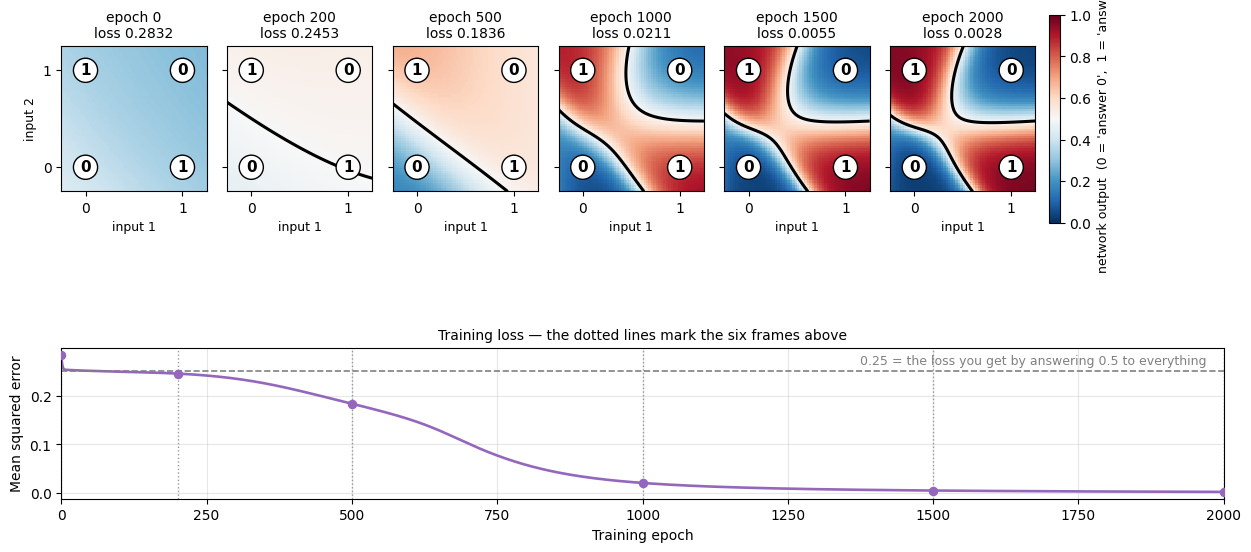


📋 Step table — the network's four answers at each frame
    epoch     loss   (0,0)  (0,1)  (1,0)  (1,1)   <- input
                       0      1      1      0     <- correct answer (XOR)
   --------------------------------------------------------------
        0   0.2832    0.39   0.34   0.33   0.29
      200   0.2453    0.47   0.52   0.50   0.53
      500   0.1836    0.27   0.65   0.55   0.58
     1000   0.0211    0.10   0.86   0.85   0.18
     1500   0.0055    0.05   0.93   0.92   0.09
     2000   0.0028    0.04   0.95   0.94   0.06

   Read down each of the four columns: they start bunched together near 0.5
   (the network refusing to commit) and only separate into 0 / 1 / 1 / 0 late on.


In [7]:
# ── STORYBOARD: what actually happened during those 2,000 epochs ─────────────
# WHAT: six frames of the network's output surface over the whole input square,
#       drawn from the weights we froze at epochs 0, 200, 500, 1000, 1500 and 2000,
#       plus the loss curve underneath with those six moments marked.
# WHY: "a hidden layer bends the boundary" is a claim about a PROCESS. A row of
#      frames is an honest animation — every frame is a real saved training state,
#      not an illustration — and unlike a video it always renders.
import numpy as np
import matplotlib.pyplot as plt

def surface(weights, points):
    """Run one frozen snapshot of the network forward over a grid of inputs."""
    W1, b1, W2, b2 = weights
    hidden = nn.sigmoid(points @ W1 + b1)   # input -> hidden layer
    return nn.sigmoid(hidden @ W2 + b2)     # hidden -> output, a number in (0, 1)

frames = sorted(nn.snapshots)               # the epochs we saved during training
grid_axis = np.linspace(-0.25, 1.25, 60)    # 60x60 grid over (and just past) the unit square
gx, gy = np.meshgrid(grid_axis, grid_axis)
grid_points = np.c_[gx.ravel(), gy.ravel()]

fig = plt.figure(figsize=(15, 6.4))
spec = fig.add_gridspec(2, len(frames), height_ratios=[1.5, 1.0], hspace=0.62, wspace=0.14)
top_axes = []

for col, epoch in enumerate(frames):
    ax = fig.add_subplot(spec[0, col])
    top_axes.append(ax)
    Z = surface(nn.snapshots[epoch], grid_points).reshape(gx.shape)
    mesh = ax.pcolormesh(gx, gy, Z, cmap="RdBu_r", vmin=0, vmax=1, shading="auto")
    # Draw the 0.5 decision boundary only if the surface actually crosses 0.5.
    # Early on it does not: the whole square is on one side, so there is no boundary yet.
    if Z.min() < 0.5 < Z.max():
        ax.contour(gx, gy, Z, levels=[0.5], colors="black", linewidths=2.2)
    for (px, py), target in zip(X_xor, y_xor.ravel()):
        ax.text(px, py, str(int(target)), ha="center", va="center",
                fontsize=11, fontweight="bold", zorder=5,
                bbox=dict(boxstyle="circle,pad=0.30", facecolor="white", edgecolor="black"))
    ax.set_title(f"epoch {epoch}\nloss {nn.loss_history[epoch]:.4f}", fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlabel("input 1", fontsize=9)
    if col == 0:
        ax.set_ylabel("input 2", fontsize=9)
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-0.25, 1.25)
    ax.set_ylim(-0.25, 1.25)
    ax.set_aspect("equal")

bar = fig.colorbar(mesh, ax=top_axes, location="right", shrink=0.92, pad=0.012)
bar.set_label("network output  (0 = 'answer 0',  1 = 'answer 1')", fontsize=9)

ax_loss = fig.add_subplot(spec[1, :])
ax_loss.plot(nn.loss_history, color="tab:purple", linewidth=1.9)
for epoch in frames:
    ax_loss.axvline(epoch, color="0.6", linestyle=":", linewidth=1)
ax_loss.scatter(frames, [nn.loss_history[e] for e in frames],
                color="tab:purple", s=34, zorder=5)
ax_loss.axhline(0.25, color="grey", linestyle="--", linewidth=1.2)
ax_loss.text(len(nn.loss_history) * 0.985, 0.258,
             "0.25 = the loss you get by answering 0.5 to everything",
             ha="right", va="bottom", fontsize=9, color="grey")
ax_loss.set_xlim(0, len(nn.loss_history) - 1)
ax_loss.set_xlabel("Training epoch")
ax_loss.set_ylabel("Mean squared error")
ax_loss.set_title("Training loss — the dotted lines mark the six frames above", fontsize=10)
ax_loss.grid(alpha=0.3)

plt.show()

# The same six frames as a table, because a number is easier to quote than a colour.
print("\n📋 Step table — the network's four answers at each frame")
print(f"   {'epoch':>6} {'loss':>8}   " +
      "  ".join(f"({int(a)},{int(b)})" for a, b in X_xor) + "   <- input")
print(f"   {'':>6} {'':>8}   " +
      "  ".join(f"{int(t):^5}" for t in y_xor.ravel()) + "   <- correct answer (XOR)")
print("   " + "-" * 62)
for epoch in frames:
    outputs = surface(nn.snapshots[epoch], X_xor.astype(float)).ravel()
    print(f"   {epoch:>6} {nn.loss_history[epoch]:>8.4f}   " +
          "  ".join(f"{o:5.2f}" for o in outputs))
print("\n   Read down each of the four columns: they start bunched together near 0.5")
print("   (the network refusing to commit) and only separate into 0 / 1 / 1 / 0 late on.")

**📊 Read the storyboard — six real training states, left to right.**

**Frame `epoch 0`** is the untrained network: the square is one flat wash of pale blue and there is **no black line at all**, because the output never crosses 0.5 — the network answers "about 0.4" to all four inputs. **Frame `epoch 200`** is barely different; the loss curve underneath is still sitting on the grey 0.25 line, which is exactly the loss you get by answering 0.5 to everything. That flat stretch is real and it is the part students find surprising: for the first few hundred epochs, backpropagation looks like it is doing nothing.

Then the surface **tears**. By `epoch 1000` a black boundary has appeared and bent — it is not a straight line, and it could not be, because no straight line can put `(0,0)` and `(1,1)` on one side and `(0,1)` and `(1,0)` on the other. That is the whole point of Part 5: a single linear boundary provably cannot solve XOR, and the hidden layer is what buys the bend. By `epoch 2000` the two corners marked `0` sit in deep blue and the two marked `1` sit in deep red.

The step table prints the same six moments as numbers, so you can quote them: the four outputs start bunched around 0.5 and end at roughly 0.04 / 0.95 / 0.95 / 0.06.

## Part 6: Cross-Validation

**The Story**: How do we know if our model will work on new data? We need to test it properly!

**BEFORE**: We test on the same data we trained on - this gives overly optimistic results (overfitting).
**AFTER**: Cross-validation tests on different data - gives realistic estimate of how well the model will perform!

✅ AFTER: Cross-Validation (Proper Model Evaluation)

   Data: 400 real census block groups (target in units of $100,000)

📊 THE PROBLEM:
   • If we test on training data, model looks perfect (overfitting)
   • But it might fail on new, unseen data!
   • We need realistic performance estimate

✅ THE SOLUTION: Cross-Validation
   • Split data into K folds (e.g., 5 folds)
   • Train on 4 folds, test on 1 fold
   • Repeat 5 times (each fold used as test once)
   • Average results → Realistic performance!

📊 Performing 5-Fold Cross-Validation:
   Fold 1: MSE = 0.5746
   Fold 2: MSE = 0.8388
   Fold 3: MSE = 0.7748
   Fold 4: MSE = 0.5755
   Fold 5: MSE = 0.5230

   ✅ Average MSE: 0.6573 ± 0.1252
   ✅ In dollars: typical error ≈ $81,076
   ✅ This is realistic performance on new data!

   ⚠️  Look at the spread between folds: the worst fold scores 0.839 and the best 0.523.
      On real data, which rows land in your test set genuinely changes the answer —
      which is exactly why a single t

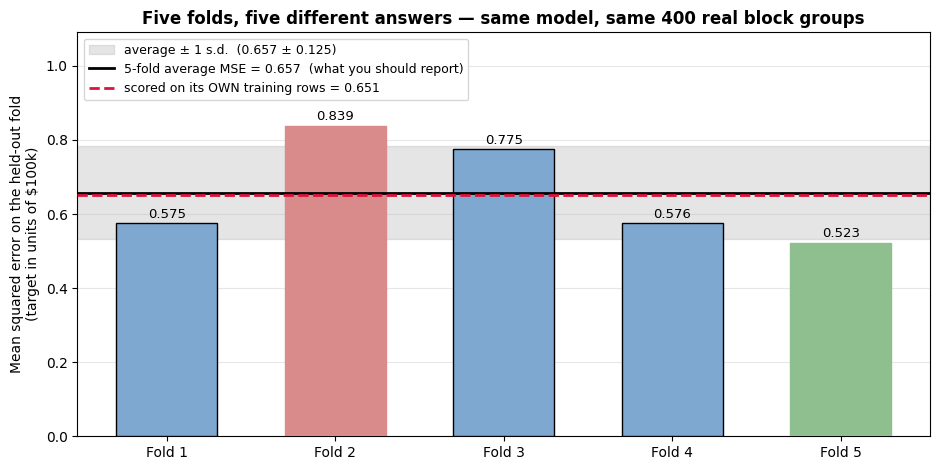


📊 Read the figure:
   • Worst fold 0.839 (red bar), best fold 0.523 (green bar) — a 60% difference produced by nothing
     but which rows happened to be held out. A single train/test split reports ONE of
     those bars and calls it 'the' score.
   • The red dashed line (0.651) is the score on the training rows themselves.
     Here it sits INSIDE the fold spread, barely below the average — because a straight
     line through ONE feature has too little capacity to memorise 400 rows.
     The optimism this section warns about grows with model capacity: see Part 8, where
     an unpruned decision tree scores 100% on its own training data and much less on
     held-out data. Cross-validation is the check that catches BOTH cases.


In [8]:
# Cross-Validation: Proper Model Evaluation
# BEFORE: Test on training data → Overly optimistic (overfitting)
# AFTER: Cross-validation → Realistic performance estimate!

from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_squared_error
import pandas as pd
import numpy as np

print("=" * 70)
print("✅ AFTER: Cross-Validation (Proper Model Evaluation)")
print("=" * 70)
print()

# REAL DATA again: the same California census block groups from Part 2, so the folds
# below measure a model on data that really exists.
california = fetch_california_housing()
housing_cv = pd.DataFrame(california.data, columns=california.feature_names)
housing_cv["MedHouseVal"] = california.target
housing_cv = housing_cv.sample(n=400, random_state=42).reset_index(drop=True)

X = housing_cv[["MedInc"]].to_numpy()
y = housing_cv["MedHouseVal"].to_numpy()

print(f"   Data: {len(X)} real census block groups (target in units of $100,000)")
print()

print("📊 THE PROBLEM:")
print("   • If we test on training data, model looks perfect (overfitting)")
print("   • But it might fail on new, unseen data!")
print("   • We need realistic performance estimate")
print()

print("✅ THE SOLUTION: Cross-Validation")
print("   • Split data into K folds (e.g., 5 folds)")
print("   • Train on 4 folds, test on 1 fold")
print("   • Repeat 5 times (each fold used as test once)")
print("   • Average results → Realistic performance!")
print()

# Create model
model = LinearRegression()

# Cross-validation (K-Fold with K=5)
print("📊 Performing 5-Fold Cross-Validation:")
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')

print(f"   Fold 1: MSE = {-cv_scores[0]:.4f}")
print(f"   Fold 2: MSE = {-cv_scores[1]:.4f}")
print(f"   Fold 3: MSE = {-cv_scores[2]:.4f}")
print(f"   Fold 4: MSE = {-cv_scores[3]:.4f}")
print(f"   Fold 5: MSE = {-cv_scores[4]:.4f}")
print()
print(f"   ✅ Average MSE: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   ✅ In dollars: typical error ≈ ${np.sqrt(-cv_scores.mean()) * 100_000:,.0f}")
print(f"   ✅ This is realistic performance on new data!")
print()
print(f"   ⚠️  Look at the spread between folds: the worst fold scores "
      f"{-cv_scores.min():.3f} and the best {-cv_scores.max():.3f}.")
print("      On real data, which rows land in your test set genuinely changes the answer —")
print("      which is exactly why a single train/test split can flatter or unfairly punish")
print("      a model, and why we average across folds.")

print("\n🔗 HOW THIS SOLVES THE PROBLEM:")
print("   ❌ BEFORE: Test on training data → Overly optimistic (overfitting)")
print("   ✅ AFTER: Cross-validation → Realistic estimate of performance!")
print("   • Tests on different data each time")
print("   • Average gives reliable estimate")
print("   • Know how model will perform on new data!")

print("\n📊 BEFORE vs AFTER:")
print("   BEFORE: Train on all data, test on same data → Perfect score (misleading!)")
print("   AFTER: Cross-validation → Realistic score (trustworthy!)")

# ── SEE IT: how much the answer moves depending on which rows land in the test fold ──
# WHAT: one bar per fold (the MSE it scored on the rows it never saw), the average
#       across folds, and — for contrast — the error you would report by scoring the
#       model on the very rows it was fitted on.
# WHY: the warning printed just above is five numbers in a list. As bars, the spread
#      is a thing you can point at in class.
import matplotlib.pyplot as plt

fold_mse = -cv_scores                      # cross_val_score returns NEGATIVE MSE
mean_mse, std_mse = fold_mse.mean(), fold_mse.std()

# The "BEFORE" of this section: fit on all 400 rows, then score on those same 400 rows.
in_sample_mse = mean_squared_error(y, LinearRegression().fit(X, y).predict(X))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
bars = ax.bar([f"Fold {i + 1}" for i in range(len(fold_mse))], fold_mse,
              color="#7fa8d1", edgecolor="black", width=0.6, zorder=3)
bars[int(fold_mse.argmax())].set_color("#d98b8b")   # worst fold, in red
bars[int(fold_mse.argmin())].set_color("#8fbf8f")   # best fold, in green
ax.axhspan(mean_mse - std_mse, mean_mse + std_mse, color="grey", alpha=0.20, zorder=1,
           label=f"average ± 1 s.d.  ({mean_mse:.3f} ± {std_mse:.3f})")
ax.axhline(mean_mse, color="black", linewidth=2, zorder=4,
           label=f"5-fold average MSE = {mean_mse:.3f}  (what you should report)")
ax.axhline(in_sample_mse, color="crimson", linestyle="--", linewidth=2, zorder=4,
           label=f"scored on its OWN training rows = {in_sample_mse:.3f}")
for bar, value in zip(bars, fold_mse):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f"{value:.3f}",
            ha="center", fontsize=9.5)
ax.set_ylabel("Mean squared error on the held-out fold\n(target in units of $100k)")
ax.set_title("Five folds, five different answers — same model, same 400 real block groups",
             fontweight="bold")
ax.set_ylim(0, max(fold_mse.max(), in_sample_mse) * 1.30)
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

print("\n📊 Read the figure:")
print(f"   • Worst fold {fold_mse.max():.3f} (red bar), best fold {fold_mse.min():.3f} (green bar) — "
      f"a {(fold_mse.max() / fold_mse.min() - 1) * 100:.0f}% difference produced by nothing")
print("     but which rows happened to be held out. A single train/test split reports ONE of")
print("     those bars and calls it 'the' score.")
print(f"   • The red dashed line ({in_sample_mse:.3f}) is the score on the training rows themselves.")
print("     Here it sits INSIDE the fold spread, barely below the average — because a straight")
print("     line through ONE feature has too little capacity to memorise 400 rows.")
print("     The optimism this section warns about grows with model capacity: see Part 8, where")
print("     an unpruned decision tree scores 100% on its own training data and much less on")
print("     held-out data. Cross-validation is the check that catches BOTH cases.")

**📊 Read the figure.** Five bars, one per fold, each showing the error the *same* model scored on the 80 block groups it was not trained on. They are not the same height: the red bar (fold 2) is about 60% worse than the green one (fold 5), and nothing changed between them except which rows were held out.

The black line is the average of the five — that is the number you are entitled to report. The grey band is one standard deviation, and it is wide enough that quoting any single fold as "the model's error" would be a choice, not a measurement.

The red dashed line is the score on the model's own training rows. Be careful here, because it is *not* dramatically lower: it sits inside the spread of the folds. A straight line through a single feature has almost no capacity to memorise 400 rows, so scoring it on its own data flatters it hardly at all. That is honest, and it is the useful lesson — the optimism this section warns about scales with model capacity. Part 8 shows the other extreme: an unpruned decision tree that scores a perfect 100% on its own training data. Cross-validation is the one check that catches both cases without you having to guess in advance which you are in.

## Part 7: Decision Trees

**The Story**: Sometimes decisions are simple - just ask yes/no questions!

**BEFORE**: Complex models are hard to understand.
**AFTER**: Decision trees make decisions by asking simple yes/no questions - easy to understand and visualize!

✅ AFTER: Decision Trees (Simple Yes/No Questions)

📊 Problem: Identify a real iris species from four ruler measurements
   150 real flowers, 4 features, 3 species
   Species: setosa, versicolor, virginica

📊 Decision Tree Decision Process:
   The tree asks simple yes/no questions about real measurements:
   1. Is petal length above some number of centimetres? → Yes/No
   2. Is petal width above some number of centimetres? → Yes/No
   3. Based on the answers, predict the species

✅ Model accuracy on held-out real flowers: 100.0% (30 of 30)
   ⚠️  Do not over-read a perfect score on 30 flowers. Iris is an easy,
      well-separated dataset and the test set is small; Part 6's cross-validation
      exists precisely because one lucky split proves very little.

📊 The rules the tree actually learned from the real measurements:
|--- Petal length (cm) <= 2.45
|   |--- class: setosa
|--- Petal length (cm) >  2.45
|   |--- Petal length (cm) <= 4.75
|   |   |--- Petal width (cm) <= 1.65
|   |   |

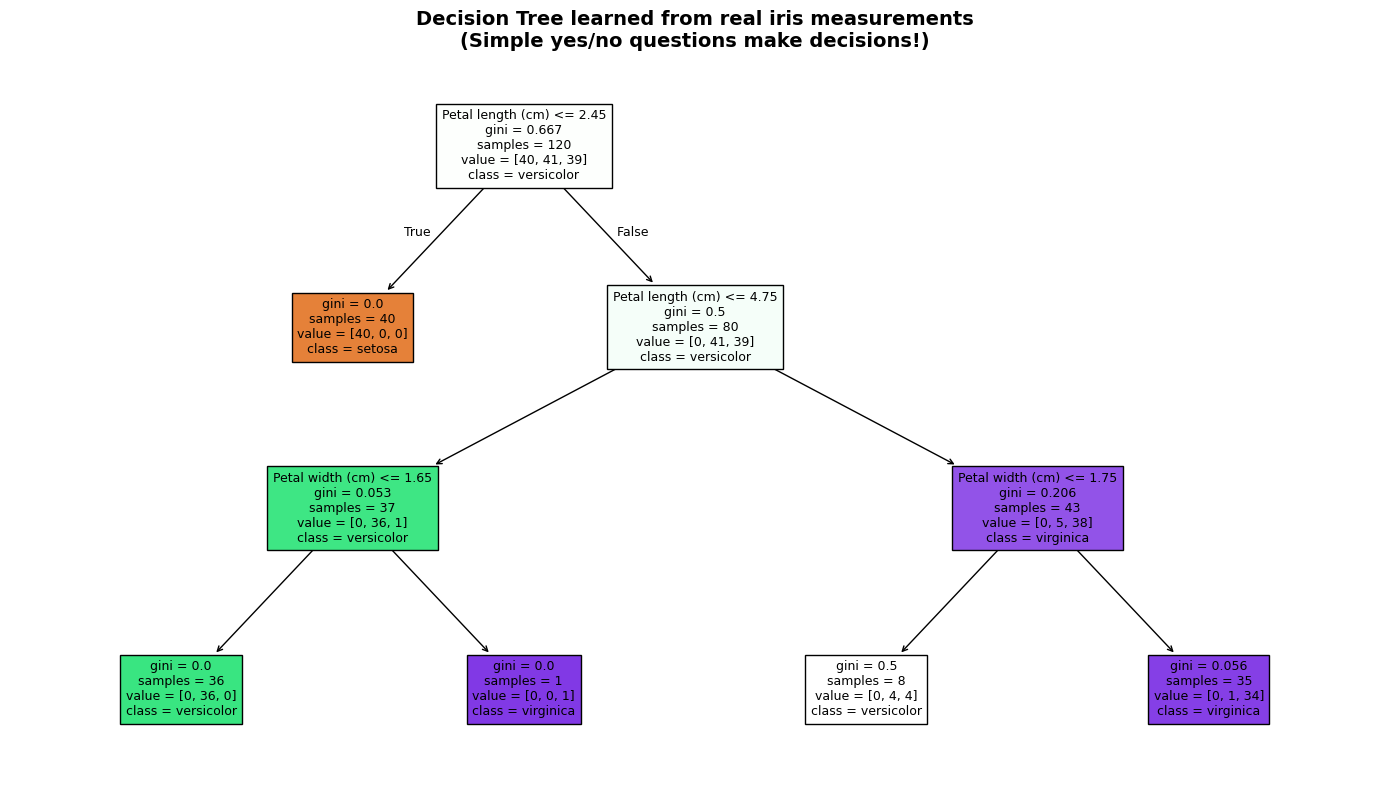

🔗 HOW THIS HELPS IN REAL LIFE:
   • Medical: 'Has fever? → Yes → 'Has cough? → Yes → Likely flu'
   • Business: 'Revenue > threshold? → Yes → 'Profit > threshold? → Expand'
   • Customer Service: Ask questions to route to right department

📊 BEFORE vs AFTER:
   BEFORE: Complex model → Hard to understand why decisions made
   AFTER: Decision tree → Clear, understandable decision process!


In [9]:
# Decision Trees: Simple Yes/No Questions
# BEFORE: Complex models are hard to understand
# AFTER: Decision trees ask simple yes/no questions - easy to understand!

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("✅ AFTER: Decision Trees (Simple Yes/No Questions)")
print("=" * 70)
print()

# REAL DATA: all three iris species, all four ruler measurements. A tree on real
# measurements produces thresholds you can check against an actual flower.
iris_tree = load_iris()
X = iris_tree.data
y = iris_tree.target
feature_labels = ["Sepal length (cm)", "Sepal width (cm)",
                  "Petal length (cm)", "Petal width (cm)"]

print("📊 Problem: Identify a real iris species from four ruler measurements")
print(f"   {len(X)} real flowers, {X.shape[1]} features, {len(iris_tree.target_names)} species")
print(f"   Species: {', '.join(iris_tree.target_names)}")
print()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train decision tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Make predictions
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("📊 Decision Tree Decision Process:")
print("   The tree asks simple yes/no questions about real measurements:")
print("   1. Is petal length above some number of centimetres? → Yes/No")
print("   2. Is petal width above some number of centimetres? → Yes/No")
print("   3. Based on the answers, predict the species")
print()

print(f"✅ Model accuracy on held-out real flowers: {accuracy:.1%} "
      f"({int(round(accuracy * len(y_test)))} of {len(y_test)})")
print(f"   ⚠️  Do not over-read a perfect score on {len(y_test)} flowers. Iris is an easy,")
print(f"      well-separated dataset and the test set is small; Part 6's cross-validation")
print(f"      exists precisely because one lucky split proves very little.")
print()
print("📊 The rules the tree actually learned from the real measurements:")
print(export_text(dt, feature_names=feature_labels,
                  class_names=list(iris_tree.target_names)))
print("   Every threshold above is a real number of centimetres you could measure")
print("   with a ruler — which is what makes a tree explainable.")
print()

# Visualize decision tree
plt.figure(figsize=(14, 8))
plot_tree(dt, filled=True, feature_names=feature_labels,
          class_names=list(iris_tree.target_names), fontsize=9)
plt.title('Decision Tree learned from real iris measurements\n(Simple yes/no questions make decisions!)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("🔗 HOW THIS HELPS IN REAL LIFE:")
print("   • Medical: 'Has fever? → Yes → 'Has cough? → Yes → Likely flu'")
print("   • Business: 'Revenue > threshold? → Yes → 'Profit > threshold? → Expand'")
print("   • Customer Service: Ask questions to route to right department")
print()
print("📊 BEFORE vs AFTER:")
print("   BEFORE: Complex model → Hard to understand why decisions made")
print("   AFTER: Decision tree → Clear, understandable decision process!")


**📊 Read the tree, top down.** Each box shows the question being asked, the gini impurity (0 means the box holds one species only), how many training flowers reached it, and how they split.

The root asks a single question — *is the petal shorter than 2.45 cm?* — and the "True" branch lands immediately on a **pure leaf: 40 setosa, gini 0.0**, no further questions needed. One measurement, one threshold, one species completely separated. That is why decision trees are the model people trust to explain themselves: this half of the problem is solved by a rule you could apply with a ruler.

Everything below the root is the *hard* half — telling versicolor from virginica. It takes two more questions, and it still ends with a leaf holding **4 versicolor and 4 virginica (gini 0.5)**, a box the tree gives up on. That box is the same overlap the KNN figure showed as red rings: the two species are genuinely mixed there, and changing the algorithm does not change the flowers.

## Part 8: Random Forest

**The Story**: One tree might be wrong, but many trees together are usually right!

**BEFORE**: Single decision tree might overfit or make mistakes.
**AFTER**: Random forest uses MANY trees and votes - more accurate and robust!

✅ AFTER: Random Forest (Many Trees Vote)

📊 THE PROBLEM: Single decision tree might:
   • Overfit (memorize training data)
   • Make mistakes on new data
   • Be sensitive to small changes

✅ THE SOLUTION: Random Forest
   • Train MANY decision trees (each on different data)
   • Each tree votes on the prediction
   • Final prediction = majority vote
   • More trees = more accurate and robust!

📊 Real dataset: 569 biopsies x 30 measurements
   Classes: malignant / benign



📊 Comparison on the real held-out biopsies:
   Single Decision Tree Accuracy: 91.2%
   Random Forest (100 trees) Accuracy: 95.6%
   Single tree accuracy on its OWN training data: 100.0%  ← the overfitting the forest is fixing

   ✅ Random Forest is 4.8% more accurate!
   ✅ More trees = better accuracy and more robust!

🔗 HOW THIS HELPS IN REAL LIFE:
   • Medical Diagnosis: Multiple doctors agree → More confident diagnosis
   • Recommendation Systems: Multiple algorithms vote → Better recommendations
   • Image Recognition: Multiple models agree → More reliable

📊 BEFORE vs AFTER:
   BEFORE: Single tree → Might overfit, less accurate
   AFTER: Random forest → More accurate, more robust, less overfitting!


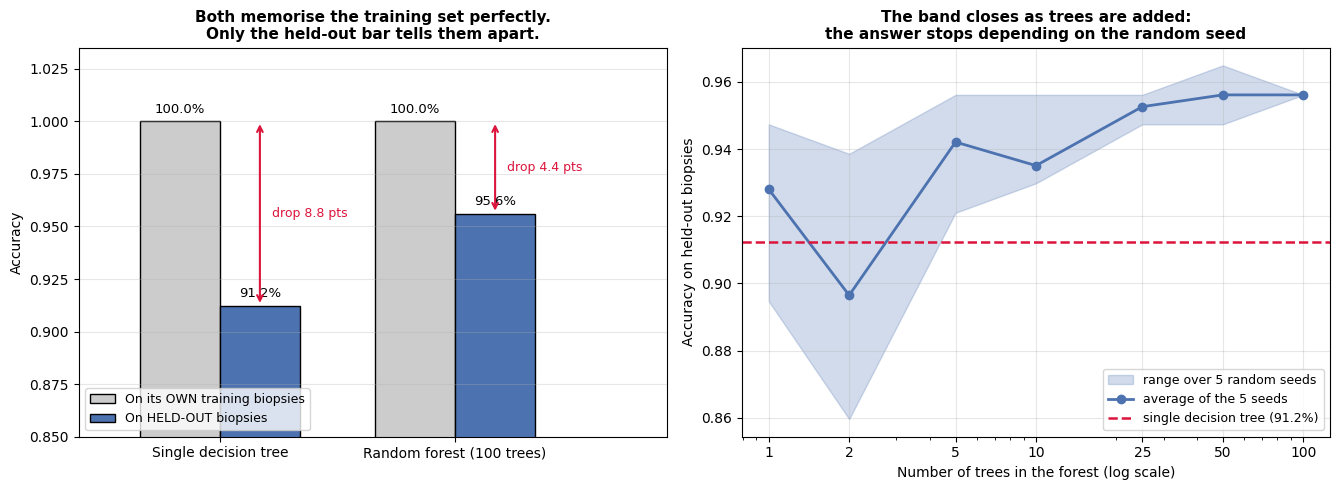


📊 Read the figure:
   • Left: BOTH models score 100% on their own training biopsies, so
     'the forest doesn't memorise' would be false. What the forest changes is the
     size of the fall on unseen data: 8.8 points for the single tree,
     4.4 points for the forest.
   • Right: with 1 tree, five different random seeds give answers spanning 5.3 accuracy
     points (89.5% to 94.7%). The blue band is that luck. By 100 trees the band
     has closed onto a single value (95.6%): the vote has averaged the luck away.
     Note the mean is NOT a clean staircase — 2 trees scores worse than 1 (two votes tie
     and the tie is broken arbitrarily). The reliable gain is the narrowing band.


In [10]:
# Random Forest: Many Trees Vote
# BEFORE: Single decision tree might overfit or make mistakes
# AFTER: Random forest uses MANY trees - more accurate and robust!

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier  # Import DecisionTreeClassifier for comparison
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

print("=" * 70)
print("✅ AFTER: Random Forest (Many Trees Vote)")
print("=" * 70)
print()

print("📊 THE PROBLEM: Single decision tree might:")
print("   • Overfit (memorize training data)")
print("   • Make mistakes on new data")
print("   • Be sensitive to small changes")
print()

print("✅ THE SOLUTION: Random Forest")
print("   • Train MANY decision trees (each on different data)")
print("   • Each tree votes on the prediction")
print("   • Final prediction = majority vote")
print("   • More trees = more accurate and robust!")
print()

# REAL DATA: all 30 measurements from the 569 Wisconsin biopsies. Thirty correlated
# real features is exactly the setting where a single tree overfits and a forest helps.
cancer_rf = load_breast_cancer()
X, y = cancer_rf.data, cancer_rf.target

print(f"📊 Real dataset: {X.shape[0]} biopsies x {X.shape[1]} measurements")
print(f"   Classes: {cancer_rf.target_names[0]} / {cancer_rf.target_names[1]}")
print()

# Split data (stratify keeps the real class ratio in both halves)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train single decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

# Train random forest (many trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 trees
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("📊 Comparison on the real held-out biopsies:")
print(f"   Single Decision Tree Accuracy: {dt_accuracy:.1%}")
print(f"   Random Forest (100 trees) Accuracy: {rf_accuracy:.1%}")
print(f"   Single tree accuracy on its OWN training data: {dt.score(X_train, y_train):.1%}"
      f"  ← the overfitting the forest is fixing")
print()

if rf_accuracy > dt_accuracy:
    improvement = (rf_accuracy - dt_accuracy) / dt_accuracy * 100
    print(f"   ✅ Random Forest is {improvement:.1f}% more accurate!")
    print("   ✅ More trees = better accuracy and more robust!")
else:
    print("   ✅ Both perform well on this dataset")

print("\n🔗 HOW THIS HELPS IN REAL LIFE:")
print("   • Medical Diagnosis: Multiple doctors agree → More confident diagnosis")
print("   • Recommendation Systems: Multiple algorithms vote → Better recommendations")
print("   • Image Recognition: Multiple models agree → More reliable")
print()
print("📊 BEFORE vs AFTER:")
print("   BEFORE: Single tree → Might overfit, less accurate")
print("   AFTER: Random forest → More accurate, more robust, less overfitting!")

# ── SEE IT: what 100 trees actually buy you ──────────────────────────────────
# WHAT: (left) each model scored twice — on its own training biopsies and on the
#       held-out ones; (right) held-out accuracy as trees are added, repeated with
#       five different random seeds so the luck-of-the-draw is visible as a band.
# WHY: "more trees = better" is the kind of claim that has to be measured, not asserted.
import matplotlib.pyplot as plt

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 5.0))

# ---- Left panel: training score vs held-out score, for both models ----
train_scores = [dt.score(X_train, y_train), rf.score(X_train, y_train)]
test_scores = [dt_accuracy, rf_accuracy]
xpos = np.arange(2)
width = 0.34
axA.bar(xpos - width / 2, train_scores, width, color="#cccccc", edgecolor="black",
        label="On its OWN training biopsies")
axA.bar(xpos + width / 2, test_scores, width, color="#4c72b0", edgecolor="black",
        label="On HELD-OUT biopsies")
for i in range(2):
    axA.text(xpos[i] - width / 2, train_scores[i] + 0.004, f"{train_scores[i]:.1%}",
             ha="center", fontsize=9.5)
    axA.text(xpos[i] + width / 2, test_scores[i] + 0.004, f"{test_scores[i]:.1%}",
             ha="center", fontsize=9.5)
    axA.annotate("", xy=(xpos[i] + width / 2, test_scores[i]),
                 xytext=(xpos[i] + width / 2, train_scores[i]),
                 arrowprops=dict(arrowstyle="<->", color="crimson", lw=1.5))
    axA.text(xpos[i] + width / 2 + 0.05, (train_scores[i] + test_scores[i]) / 2,
             f"drop {(train_scores[i] - test_scores[i]) * 100:.1f} pts",
             color="crimson", fontsize=9, va="center")
axA.set_xticks(xpos)
axA.set_xticklabels(["Single decision tree", "Random forest (100 trees)"])
axA.set_xlim(-0.6, 1.9)
axA.set_ylim(0.85, 1.035)
axA.set_ylabel("Accuracy")
axA.set_title("Both memorise the training set perfectly.\nOnly the held-out bar tells them apart.",
              fontweight="bold", fontsize=11)
axA.legend(loc="lower left", fontsize=9)
axA.grid(axis="y", alpha=0.3)

# ---- Right panel: does the answer stop depending on luck as trees are added? ----
sizes = [1, 2, 5, 10, 25, 50, 100]
means, lows, highs = [], [], []
for n_trees in sizes:
    seeds = [RandomForestClassifier(n_estimators=n_trees, random_state=s)
             .fit(X_train, y_train).score(X_test, y_test) for s in range(5)]
    means.append(float(np.mean(seeds)))
    lows.append(min(seeds))
    highs.append(max(seeds))
axB.fill_between(sizes, lows, highs, alpha=0.25, color="#4c72b0",
                 label="range over 5 random seeds")
axB.plot(sizes, means, "o-", color="#4c72b0", linewidth=2, label="average of the 5 seeds")
axB.axhline(dt_accuracy, color="crimson", linestyle="--", linewidth=1.8,
            label=f"single decision tree ({dt_accuracy:.1%})")
axB.set_xscale("log")
axB.set_xticks(sizes)
axB.set_xticklabels([str(s) for s in sizes])
axB.set_xlabel("Number of trees in the forest (log scale)")
axB.set_ylabel("Accuracy on held-out biopsies")
axB.set_title("The band closes as trees are added:\nthe answer stops depending on the random seed",
              fontweight="bold", fontsize=11)
axB.legend(loc="lower right", fontsize=9)
axB.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Read the figure:")
print(f"   • Left: BOTH models score {train_scores[0]:.0%} on their own training biopsies, so")
print("     'the forest doesn't memorise' would be false. What the forest changes is the")
print(f"     size of the fall on unseen data: {(train_scores[0] - test_scores[0]) * 100:.1f} points for the single tree,")
print(f"     {(train_scores[1] - test_scores[1]) * 100:.1f} points for the forest.")
print(f"   • Right: with 1 tree, five different random seeds give answers spanning "
      f"{(highs[0] - lows[0]) * 100:.1f} accuracy")
print(f"     points ({lows[0]:.1%} to {highs[0]:.1%}). The blue band is that luck. By 100 trees the band")
print(f"     has closed onto a single value ({means[-1]:.1%}): the vote has averaged the luck away.")
print("     Note the mean is NOT a clean staircase — 2 trees scores worse than 1 (two votes tie")
print("     and the tie is broken arbitrarily). The reliable gain is the narrowing band.")

**📊 Read the figure — two panels making two different points.**

*Left:* each model scored twice. The grey bars are both at **100%** — the forest memorises its training biopsies just as completely as the single tree does, so "the forest doesn't overfit" would be the wrong lesson. The difference is the red arrow: how far each model *falls* when it meets biopsies it has never seen. The single tree drops much further than the forest does. What ensembling fixes is not the memorising, it is the cost of the memorising.

*Right:* held-out accuracy as trees are added, with each forest size retrained under five different random seeds. The blue band is the spread between those seeds — pure luck. At one tree the band is several accuracy points tall; by 100 trees it has closed to a single value, meaning all five seeds agree exactly. Read the band, not just the line: the dependable payoff of a forest is that **the answer stops depending on the seed**. And note the mean is not a tidy staircase — two trees actually scores *worse* than one, because two votes can tie. Anyone who tells you accuracy rises monotonically with tree count has not plotted it.

## Part 9: Real-World Application: Complete ML Pipeline

**The Story**: Let's build a complete machine learning system from scratch - this is how AI works in real life!

**BEFORE**: We've seen individual algorithms, but not how they work together.
**AFTER**: We build a complete system that combines everything - data, training, evaluation, and deployment!

✅ AFTER: Real-World Application - Complete ML Pipeline

📊 REAL-LIFE EXAMPLE: House Value Prediction on Real Census Data
   This is what real AI systems do:
   1. Get data
   2. Prepare data
   3. Train model (uses optimization!)
   4. Evaluate model
   5. Make predictions on new data

📊 Step 1: Data Collection
   ✅ Loaded 2,000 real census block groups (sampled from 20,640, random_state=42)
   Features: [Median income ($10k), House age (years), Average rooms]
   Target: Median house value ($100k), real range $30,000 to $500,001

📊 Step 2: Data Preparation
   ✅ Split data: 1600 training, 400 testing

📊 Step 3: Model Training (Using Optimization!)
   Training multiple models to find best one...

   Training Linear Regression...
      ✅ R² Score: 0.521 (closer to 1 is better)
      ✅ MSE: 0.6620 in ($100k)² — i.e. a typical error of $81,364 (lower is better)

   Training Random Forest...
      ✅ R² Score: 0.584 (closer to 1 is better)
      ✅ MSE: 0.5756 in ($100k)² — i.e. a typical error

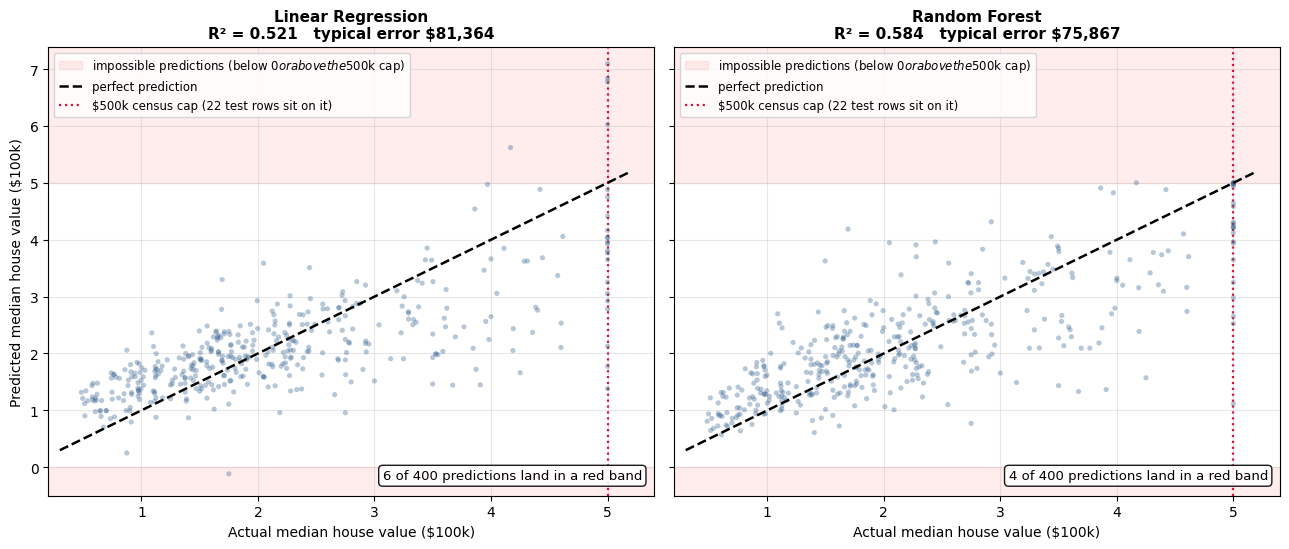


📊 Read the figure:
   • Linear Regression: predictions run from $-11,597 to $709,237, against a real range of $48,500 to $500,001.
   • Random Forest: predictions run from $56,995 to $500,001, against a real range of $48,500 to $500,001.
   • The straight-line model cannot stop itself: extend a line far enough and it
     predicts negative house prices. The forest, which only ever averages values it
     has actually seen, physically cannot leave the real range.
   • The vertical dotted line is the census cap. Both models spray predictions across
     it, because those block groups are all recorded as exactly $500,000 whatever they
     were really worth. No model can recover information the data set threw away.


In [11]:
# Real-World Application: Complete ML Pipeline
# BEFORE: Individual algorithms, but not how they work together
# AFTER: Complete system from data to predictions - this is REAL-LIFE AI!

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("✅ AFTER: Real-World Application - Complete ML Pipeline")
print("=" * 70)
print()

print("📊 REAL-LIFE EXAMPLE: House Value Prediction on Real Census Data")
print("   This is what real AI systems do:")
print("   1. Get data")
print("   2. Prepare data")
print("   3. Train model (uses optimization!)")
print("   4. Evaluate model")
print("   5. Make predictions on new data")
print()

# Step 1: Load REAL data — no simulation anywhere in this pipeline
california_pipe = fetch_california_housing()
pipe_df = pd.DataFrame(california_pipe.data, columns=california_pipe.feature_names)
pipe_df["MedHouseVal"] = california_pipe.target

# Classroom-size the data honestly: 2,000 block groups, random_state=42.
n_samples = 2000
pipe_df = pipe_df.sample(n=n_samples, random_state=42).reset_index(drop=True)

FEATURES = ["MedInc", "HouseAge", "AveRooms"]
X = pipe_df[FEATURES].to_numpy()
y = pipe_df["MedHouseVal"].to_numpy()

print("📊 Step 1: Data Collection")
print(f"   ✅ Loaded {n_samples:,} real census block groups "
      f"(sampled from {california_pipe.data.shape[0]:,}, random_state=42)")
print(f"   Features: [Median income ($10k), House age (years), Average rooms]")
print(f"   Target: Median house value ($100k), real range "
      f"${y.min() * 100_000:,.0f} to ${y.max() * 100_000:,.0f}")
print()

# Step 2: Prepare data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("📊 Step 2: Data Preparation")
print(f"   ✅ Split data: {len(X_train)} training, {len(X_test)} testing")
print()

# Step 3: Train multiple models (compare them!)
print("📊 Step 3: Model Training (Using Optimization!)")
print("   Training multiple models to find best one...")
print()

models = {
    'Linear Regression': LinearRegression(), 'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for model_name, model in models.items():
    print(f"   Training {model_name}...")
    
    # Train model (this uses optimization internally!)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[model_name] = {
        'model': model,
        'mse': mse,
        'r2': r2,
        'predictions': y_pred
    }
    
    print(f"      ✅ R² Score: {r2:.3f} (closer to 1 is better)")
    print(f"      ✅ MSE: {mse:.4f} in ($100k)² — i.e. a typical error of "
          f"${np.sqrt(mse) * 100_000:,.0f} (lower is better)")
    print()

# Step 4: Compare models
print("📊 Step 4: Model Comparison")
print(f"   {'Model':<25} {'R² Score':<12} {'Typical error':<16}")
print("   " + "-" * 55)

best_model_name = None
best_r2 = -float('inf')

for model_name, result in results.items():
    print(f"   {model_name:<25} {result['r2']:<12.3f} "
          f"${np.sqrt(result['mse']) * 100_000:<15,.0f}")
    if result['r2'] > best_r2:
        best_r2 = result['r2']
        best_model_name = model_name

print()
print(f"✅ Best Model: {best_model_name} (R² = {best_r2:.3f})")
print()

# Step 5: Use model for predictions
print("📊 Step 5: Make Predictions on New Data")
print("   Example: a neighbourhood with a $50,000 median income, 25-year-old housing,")
print("            and about 5 rooms per household:")
new_block_group = np.array([[5.0, 25.0, 5.0]])   # MedInc ($10k), HouseAge, AveRooms
predicted_value = results[best_model_name]['model'].predict(new_block_group)[0]

print(f"   ✅ Predicted median house value: ${predicted_value * 100_000:,.0f}")
print(f"   ⚠️  Quote it with its error bar, not on its own: the best model's typical")
print(f"      error on real held-out data is "
      f"±${np.sqrt(results[best_model_name]['mse']) * 100_000:,.0f}.")
print(f"      A prediction reported without that number is a prediction pretending")
print(f"      to be a measurement.")
print()

print("🔗 HOW THIS WORKS IN REAL LIFE:")
print("   • Real Estate: Predict house prices → Help buyers/sellers")
print("   • E-commerce: Predict product demand → Manage inventory")
print("   • Healthcare: Predict patient outcomes → Help doctors")
print("   • Finance: Predict stock prices → Help investors")
print()
print("📊 COMPLETE ML PIPELINE:")
print("   1. ✅ Data Collection (real-world data)")
print("   2. ✅ Data Preparation (clean and split)")
print("   3. ✅ Model Training (uses optimization from Notebook 4!)")
print("   4. ✅ Model Evaluation (cross-validation from this notebook!)")
print("   5. ✅ Model Selection (choose best model)")
print("   6. ✅ Make Predictions (use in real life!)")
print()
print("🔗 CONNECTIONS TO ALL NOTEBOOKS:")
print("   • Notebook 1: Search algorithms → Model training searches for best parameters")
print("   • Notebook 2: Data structures → Store and organize data")
print("   • Notebook 3: Probability → Model predictions are probabilistic")
print("   • Notebook 4: Optimization → Training = optimization problem!")
print("   • This notebook: Everything comes together in machine learning!")

# ── SEE IT: predicted vs actual on the held-out block groups ─────────────────
# WHAT: every held-out block group as one dot — its real value across, the model's
#       prediction up. The dashed diagonal is where a perfect model would put them.
# WHY: R² is one number for 400 predictions. The scatter shows WHERE each model is
#      wrong, including predictions that are physically impossible.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharex=True, sharey=True)

all_preds = np.concatenate([r["predictions"] for r in results.values()])
y_lo, y_hi = min(-0.5, all_preds.min() - 0.3), max(5.5, all_preds.max() + 0.3)

for ax, (model_name, result) in zip(axes, results.items()):
    preds = result["predictions"]
    # Two pale red bands = predictions that cannot exist: below $0, or above the
    # $500k ceiling the census imposed on this target column.
    ax.axhspan(5.0, y_hi, color="red", alpha=0.07, zorder=0)
    ax.axhspan(y_lo, 0.0, color="red", alpha=0.07, zorder=0,
               label="impossible predictions (below $0 or above the $500k cap)")
    ax.scatter(y_test, preds, s=14, alpha=0.35, color="#33608f", edgecolors="none", zorder=3)
    ax.plot([0.3, 5.2], [0.3, 5.2], "k--", linewidth=1.8, zorder=4,
            label="perfect prediction")
    ax.axvline(5.0, color="crimson", linestyle=":", linewidth=1.6, zorder=2,
               label=f"$500k census cap ({int((y_test >= 4.999).sum())} test rows sit on it)")
    ax.set_xlim(0.2, 5.4)
    ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel("Actual median house value ($100k)")
    ax.set_title(f"{model_name}\nR² = {result['r2']:.3f}   typical error "
                 f"${np.sqrt(result['mse']) * 100_000:,.0f}", fontweight="bold", fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=8.5)
    n_impossible = int(((preds < 0) | (preds > 5.0)).sum())
    ax.text(0.98, 0.03, f"{n_impossible} of {len(preds)} predictions land in a red band",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

axes[0].set_ylabel("Predicted median house value ($100k)")
plt.tight_layout()
plt.show()

print("\n📊 Read the figure:")
for model_name, result in results.items():
    preds = result["predictions"]
    print(f"   • {model_name}: predictions run from ${preds.min() * 100_000:,.0f} to "
          f"${preds.max() * 100_000:,.0f}, against a real range of "
          f"${y_test.min() * 100_000:,.0f} to ${y_test.max() * 100_000:,.0f}.")
print("   • The straight-line model cannot stop itself: extend a line far enough and it")
print("     predicts negative house prices. The forest, which only ever averages values it")
print("     has actually seen, physically cannot leave the real range.")
print("   • The vertical dotted line is the census cap. Both models spray predictions across")
print("     it, because those block groups are all recorded as exactly $500,000 whatever they")
print("     were really worth. No model can recover information the data set threw away.")

**📊 Read the figure.** Each dot is one held-out block group: its real median value across, the model's prediction up. The dashed diagonal is where every dot would sit if the model were perfect, so vertical distance from that line is the error on that neighbourhood.

Three things are visible that R² alone cannot tell you:

1. **The linear model predicts impossible houses.** Its dots run up into the top red band, past the $500k ceiling, and down into the bottom one, below $0. A straight line, extended far enough, has no way to stop. The forest's dots stay inside the real range for a structural reason worth saying out loud: a regression forest only ever averages target values it has actually seen, so it *cannot* produce a number outside them.
2. **Both models are conservative.** The clouds are flatter than the diagonal — cheap neighbourhoods are over-predicted and expensive ones under-predicted. That is what an R² near 0.5 looks like from the inside.
3. **The vertical dotted line at $500k is a defect in the data, not the model.** Every block group at or above half a million dollars was recorded as exactly 5.0 when this census extract was built, so a whole stripe of genuinely different neighbourhoods carries one identical label. Both models spray predictions across that stripe, and neither can do better: the information was thrown away before the model ever saw it.

## 💬 Discuss

Each of these is settled by a number printed above — and then argued about.

1. **Read the confusion matrix in Part 4 again.** On the real held-out biopsies: 103 benign called benign, 5 benign wrongly called malignant, **11 malignant missed**, 52 malignant caught. Accuracy 90.64%; recall on malignant tumours 82.5%. The 0.5 probability threshold that produced those numbers is *your* choice, not the model's — logistic regression handed you a probability and you rounded it. Where would you set that threshold for a screening clinic, and what does moving it cost in the other column? And the harder half: whose decision is that — the data scientist's, the clinician's, or the hospital's lawyer's?
2. **Part 8 puts a single decision tree at 91.2% on held-out biopsies and a 100-tree random forest at 95.6%** — while the same single tree scores 100% on its own training data. A client must justify every decision to a regulator and asks for "the explainable model". Do you hand them the tree? Write the two sentences you would actually say to describe the gap honestly, without either overselling the forest or pretending the tree's explainability is free.
3. **Part 6's five cross-validation folds ranged from MSE 0.5230 to 0.8388** — the worst fold is 60% worse than the best, on the same model, the same data, the same day. Only *which rows landed in the test set* changed. When a colleague reports a single train/test accuracy with no cross-validation, what is the first question you ask, and what would you accept as an answer?

---


## ⚠️ Where this breaks

Every limit below is measurable in this notebook's own output. That is the point: a model that reports its own failures is more useful than one that reports only its wins.

- **Accuracy hides the error that matters.** The logistic regression scored **90.64% accuracy** — and missed **11 malignant tumours**. The cell says so itself: *"Accuracy alone would have hidden those missed cases."* Whenever the two classes carry different costs, accuracy is the wrong headline number. Report recall, precision, or the full confusion matrix, and say which error you chose to make.
- **One feature explains one feature's worth.** Predicting house value from median income alone gave **R² = 0.6326** with a typical error of **\$75,801**. That is a real pattern, and it is far from all of it — location, house age, rooms and the ocean view are all missing, and the cell says so. A model's error is a statement about what you left out.
- **Which rows land in the test set changes the answer.** Fold MSEs 0.5230, 0.5746, 0.5755, 0.7748, 0.8388. A single split can flatter a model or unfairly punish it, and on a dataset this size the difference is not small.
- **Some errors are the data, not the model.** KNN got 7 of 9 real flowers right, and *both* mistakes sat where *versicolor* and *virginica* genuinely overlap in petal size. No algorithm resolves an ambiguity that exists in nature; more model capacity would only overfit the noise.
- **A single tree memorises.** 100% on its own training data, 91.2% on data it had not seen. Training accuracy is not evidence of anything, and any model flexible enough will reach 100% on the training set if you let it.
- **Everything here was trained on one time and one place.** 1990 California census blocks. Biopsies from one Wisconsin clinic. 150 irises measured in 1935. Applying the housing model to Riyadh property is not an extrapolation, it is a different problem with a familiar-looking column layout — and the model will still return confident numbers.
- **These datasets are far cleaner than what you will actually meet.** The WDBC labels are pathology results, which is as good as ground truth gets. In most real projects the majority of the work happens *before* the first `.fit()` — finding labels, agreeing what the label means, and discovering that two departments defined it differently.
- **The 2026 baseline has moved, and this notebook is a first survey, not a state of the art.** On medium-sized tabular data, tuned gradient-boosted trees have been the honest baseline since Grinsztajn *et al.* (2022) — not linear models, and not a hand-tuned forest. Since 2025, tabular foundation models (TabPFN-2.5, TabPFN-3) are reported to match or beat tuned tree ensembles without per-dataset tuning. The professional habit to build now is: benchmark your model against a *strong* baseline, not against manual rules. Course 04 and Course 05 do exactly that.
- **The cheaper alternative.** If a decision turns on three factors and must be auditable line by line, a written rule or a points-based scorecard is defensible, stable, and cheap to explain — which is why regulated credit and clinical scoring still use them. Learn a model when the pattern has more dimensions than a person can hold in mind, or when it changes faster than anyone can rewrite the rules.

---


## Summary: Problem → Solution Realization

### ❌ THE PROBLEM:
1. Need machines to recognize patterns or make predictions
2. Without ML: Manual rules (arbitrary, doesn't adapt)
3. This leads to poor performance on complex problems

### ✅ THE SOLUTION:
1. **Show examples**: Provide training data
2. **Let model learn**: Algorithm finds patterns automatically
3. **Test on new data**: Verify it generalizes

### 🔗 HOW THE SOLUTION SOLVES THE PROBLEM:
- ✅ Instead of manual rules → Learned patterns from data
- ✅ Instead of rigid → Flexible, adapts to real patterns
- ✅ Instead of arbitrary → Based on actual relationships

### 📊 BEFORE vs AFTER:
- **BEFORE**: Problem → Manual rules → Poor performance on complex problems
- **AFTER**: Problem → Machine learning → Learns patterns automatically, good performance!

### 🔗 How This Connects to Other Notebooks:

**This notebook combines everything you learned:**
- **Notebook 1: Search Algorithms** - ML models use algorithmic thinking. Training is like searching for the best parameters. Understanding algorithms helps you understand how models work.

- **Notebook 2: Knowledge Representation** - ML models represent learned knowledge. The patterns they learn are a form of knowledge representation - stored in model parameters.

- **Notebook 3: Learning under Uncertainty** - ML models make predictions with uncertainty. Understanding probability helps you interpret model outputs, confidence intervals, and prediction reliability.

- **Notebook 4: Optimization Techniques** - **Training ML models IS optimization!** You use gradient descent (from Notebook 4) to find parameters that minimize loss. This is the core of how models learn.

**Why this is the final notebook:**
1. **Combines all concepts**: ML = Search (for patterns) + Knowledge Representation (learned patterns) + Uncertainty (probabilistic predictions) + Optimization (training)
2. **Practical application**: All previous notebooks were foundations - this is the application
3. **Real-world AI**: Machine learning is how most modern AI systems work

### Key Takeaways:
1. **ML learns from data**: Models automatically find patterns instead of using manual rules
2. **Training is optimization**: Finding model parameters that minimize loss (uses Notebook 4 concepts!)
3. **Generalization matters**: Model must work on new data, not just training data
4. **Foundation for advanced AI**: Understanding ML basics prepares you for deep learning, NLP, computer vision

## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the technique above, exactly as it is taught. This box says where that technique sits on the 2026 map.*

A learning model is rarely shipped in 2026 as a bare `.fit()` / `.predict()` object. The unit of engineering has moved to the *system around* the model — the tools it may call, the context it is given, what happens when a step fails — and current survey work treats model and harness as one co-designed system, arguing that task completion depends on the interaction between model capability, runtime infrastructure, task structure and evaluation design rather than on model quality alone (Guo *et al.*, 2026). The tool interface standardised too: the Model Context Protocol turned per-vendor function calling into a shared client/server ecosystem, and inherited a shared security surface with it (Hou *et al.*, 2025). Notice what none of that changes. Something still has to map inputs to a decision; it still has to be scored on data it did not see; it still has to beat a strong baseline rather than the manual rules of Part 1. Those habits are formed here, on k-NN, logistic regression, a hand-written network, a tree and a forest — and on tabular data of this size those models are not a stepping stone to something better, they are the right tool.

**Read:** Hou *et al.* (2025), <https://arxiv.org/abs/2503.23278> · Guo *et al.* (2026), <https://arxiv.org/abs/2606.20683> (references 5-6 below).

---

## 📚 References

1. Cover, T., & Hart, P. (1967). *Nearest Neighbor Pattern Classification*. IEEE Transactions on Information Theory 13(1), 21-27. (the k-NN paper)
2. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning Representations by Back-Propagating Errors*. Nature 323, 533-536. (how neural networks learn)
3. Breiman, L. (2001). *Random Forests*. Machine Learning 45, 5-32.
4. Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why Do Tree-Based Models Still Outperform Deep Learning on Tabular Data?* arXiv preprint. <https://arxiv.org/abs/2207.08815>
5. Hou, X., Zhao, Y., Wang, S., & Wang, H. (2025). *Model Context Protocol (MCP): Landscape, Security Threats, and Future Research Directions*. arXiv preprint. <https://arxiv.org/abs/2503.23278> (how a model is handed tools in 2026 — and the attack surface that arrives with them)
6. Guo, J., et al. (2026). *From Question Answering to Task Completion: A Survey on Agent System and Harness Design*. arXiv preprint. <https://arxiv.org/abs/2606.20683> (model and harness as one co-designed system; the survey to read before drawing a 2026 architecture diagram)
7. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer. <https://www.statlearning.com/>